# Paper annual cycle plots

- **v5.1**:
  - Add back Obs in std table of metrics

- **v5**:
  - correct errors on individual sites normalized metrics on figures for snd and swe (values ok in score and averages over sites)
  
- **v4**:
  - correct AC with extended 0 values at SNB and SWA
  - add tables of metrics

With physics + Arctic snow code modifications v1 (subli correct v2)

In [1]:
# Env: sc2_v0
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import proplot as pplt # New plot library (https://proplot.readthedocs.io/en/latest/)
pplt.rc['savefig.dpi'] = 300 # 1200 is too big! #https://proplot.readthedocs.io/en/latest/basics.html#Creating-figures
from scipy import stats
import xesmf as xe # For regridding (https://xesmf.readthedocs.io/en/latest/)
import calendar
import os

In [2]:
# https://www.w3schools.com/python/python_classes.asp

class Site:
  def __init__(self, name, long_name, location, lat, lon, elevation, period, start, stop, period_used, run):
    self.name = name
    self.long_name = long_name
    self.location = location
    self.lat = lat
    self.lon = lon
    self.elevation = elevation
    self.period = period
    self.start = start
    self.stop = stop
    self.period_used = period_used
    self.run = run

exps = [
    'DEF',
    # 'BUG_CORRECT',
    # 'BUG_CORRECT_TSNBT_OP1',
    'BUG_CORRECT_TSNBT_OP1_EZERO',
    # 'PHYS_ALL_SUBLI_CORRECT',
    'PHYS_ALL_SUBLI_v2',
    # 'PHYS_ALL_SUBLI_CORRECT_COMPAC',
    'PHYS_ALL_SUBLI_v2_COMPAC_v1',
    'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne', # Best without TVC (COMPACT_2.5)
    'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne', # best with TVC

]

# SnowMIP
cdp = Site('cdp', 'Col de Porte, France', '45.30°N, 5.77°E', 45.30, 5.77, '1325 m', 
           '1 October 1994 to 30 September 2014', '1994-10-01', '2014-09-30', slice('1994-10-01', '2014-09-30'), exps)

rme = Site('rme', 'Reynolds Mountain East, Idaho, USA', '43.19°N, 116.78°W', 43.19, -116.78, '2060 m', 
           '1 October 1988 to 30 September 2008', '1988-10-01', '2008-09-30', slice('1988-10-01', '2008-09-30'), exps)

snb = Site('snb', 'Senator Beck, Colorado, US', '37.91°N, 107.73°W', 37.91, -107.73, '3714 m', 
           '1 October 2005 to 30 September 2015', '2005-10-01', '2015-09-30', slice('2005-10-01', '2015-09-30'), exps)

swa = Site('swa', 'Swamp Angel, Colorado, USA', '37.91°N, 107.71°W', 37.91, -107.71, '3371 m', 
           '1 October 2005 to 30 September 2015', '2005-10-01', '2015-09-30', slice('2005-10-01', '2015-09-30'), exps)

sap = Site('sap', 'Sapporo, Japan', '43.08°N, 141.34°E', 43.08, 141.34, '15 m', 
           '1 October 2005 to 30 September 2015', '2005-10-01', '2015-09-30', slice('2005-10-01', '2015-09-30'), exps)

sod = Site('sod', 'Sodankylä, Finland', '67.37°N, 26.63°E', 67.37, 26.63, '179 m', 
           '1 October 2007 to 30 September 2014', '2007-10-01', '2014-09-30', slice('2007-10-01', '2014-09-30'), exps)

wfj = Site('wfj', 'Weissfluhjoch, Switzerland', '46.83°N, 9.81°E', 46.83, 9.81, '2540 m', 
           '1 September 1996 to 31 August 2016', '1996-10-01', '2016-08-31', slice('1996-10-01', '2016-08-31'), exps)

# Arctic 
byl = Site('byl', 'Bylot Island, Canadian high Arctic', '73.15°N, 80.00°W', 73.15, -80.00, '25 m', 
           '11 July 2013 to 25 June 2019', '2013-07-11', '2019-06-25', slice('2014-07-11', '2019-06-25'), 
           [
               'peat_DEF',
               # 'peat_BUG_CORRECT',
               # 'peat_BUG_CORRECT_TSNBT_OP1',
               'peat_BUG_CORRECT_TSNBT_OP1_EZERO',
               # 'peat_PHYS_ALL_SUBLI_CORRECT',
               'peat_PHYS_ALL_SUBLI_v2',
               # 'peat_PHYS_ALL_SUBLI_CORRECT_COMPAC',
               'peat_PHYS_ALL_SUBLI_v2_COMPAC_v1',
               'peat_PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne',
               'peat_PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne',
           ])

umt = Site('umt', 'Umiujaq TUNDRA, northeastern Canada', '56.55877°N, 76.48234°W', 56.55877, -76.48234, '132 m', 
           '28 Sept 2012 to 15 October 2021', '2012-09-28', '2021-10-15', slice('2016-09-01', '2021-08-31'), 
           [
               'DEF_correct_SH',
               # 'BUG_CORRECT',
               # 'BUG_CORRECT_TSNBT_OP1',
               'BUG_CORRECT_TSNBT_OP1_EZERO_correct_SH',
               # 'PHYS_ALL_SUBLI_CORRECT',
               'PHYS_ALL_SUBLI_v2_correct_SH',
               # 'PHYS_ALL_SUBLI_CORRECT_COMPAC',
               'PHYS_ALL_SUBLI_v2_COMPAC_v1_correct_SH',
               'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne_correct_SH',
               'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne_correct_SH',
           ])


tvc = Site('tvc', 'Trail Valley Creak, northwestern Canada', '68.74617°N, 133.50171°W', 68.74617, -133.50171, '85 m', 
           '01 Oct 2017 to 30 Sept 2019', '2017-10-01', '2019-09-30', slice('2017-10-01', '2019-09-30'), 
           [
               '1peat_2xSnowf_DEF_correct_SH',
               # '1peat_2xSnowfBUG_CORRECT',
               # '1peat_2xSnowfBUG_CORRECT_TSNBT_OP1',
               '1peat_2xSnowf_BUG_CORRECT_TSNBT_OP1_EZERO_correct_SH',
               # '1peat_2xSnowf_PHYS_ALL_SUBLI_CORRECT',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_correct_SH',
               # '1peat_2xSnowf_PHYS_ALL_SUBLI_CORRECT_COMPAC',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_v1_correct_SH',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne_correct_SH',
               '1peat_2xSnowf_PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne_correct_SH',
           ])

# umf = Site('umf', 'Umiujaq FOREST, northeastern Canada', '56.55308°N, 76.47258°W', 56.55308, -76.47258, '82 m', 
#            '26 Nov 2015 to 19 October 2021', '2015-11-26', '2021-10-19', slice('2018-09-01', '2021-08-31'), 
#            ['Ref', 'EZERO'])


In [3]:
SnowMIP_sites = [cdp, rme, snb, swa, sap, sod, wfj]
# SnowMIP_sites = [cdp, rme, snb, sap, sod, wfj]
SnowArctic_sites = [byl, umt, tvc]

path_SnowMIP = '/home/mickael-lalande/eccc/classic-develop/outputFiles/SnowMIP/'
path_SnowArctic = '/home/mickael-lalande/eccc/classic-develop/outputFiles/SnowArctic/'
path_Paul = '/home/mickael-lalande/Dropbox/data/SnowMIP/Paul/CLASS_Results'

ds_d_SnowMIP_list = []
for i, exp in enumerate(exps):
    paths_SnowMIP = [path_SnowMIP+site.name+'/'+'run_'+exp for site in SnowMIP_sites]
    # Change the syntax as the ref run is not necessarily having the same name for all sites
    paths_SnowArctic = [path_SnowArctic+site.name+'/'+'run_'+site.run[i] for site in SnowArctic_sites]
    paths = paths_SnowMIP + paths_SnowArctic
    ds_d_SnowMIP_list.append([xr.open_mfdataset(path+'/*_daily.nc').squeeze().load() for path in paths])


# ds_d_Paul_list = []
# for site in SnowMIP_sites:
#     df_Paul = pd.read_csv(path_Paul+'/CLASS_sv_REF_'+site.name+'_'+site.start[:4]+'_'+site.stop[:4]+'.txt', delim_whitespace=True)
#     df_Paul.index = pd.to_datetime(df_Paul[['year', 'month', 'day', 'hour']]).values
#     df_Paul= df_Paul.drop(columns=['year', 'month', 'day', 'hour'])
#     df_Paul.albsn = df_Paul.albsn.replace({0 : np.nan})
#     df_Paul.albs = df_Paul.albs.replace({0 : np.nan})
#     df_Paul.tsn = df_Paul.tsn.replace({-999 : np.nan})
#     df_Paul.tsns = df_Paul.tsns.replace({-999 : np.nan})
#     ds_Paul_h = df_Paul.to_xarray()
#     ds_Paul_h = ds_Paul_h.rename({'index': 'time'})
#     ds_Paul_d = ds_Paul_h.resample(time='D').mean().load()
#     ds_Paul_d = ds_Paul_d.assign_coords(layer=[0.05 , 0.225, 2.225]) # center of Paul's soil layers (DELZ = [0.1, 0.25, 3.75])
    

#     # Combine the Soil temperature in one variable
#     ds_Paul_d = ds_Paul_d.assign(
#         tsl=(('layer', 'time'), [
#             list(ds_Paul_d['tsl:1'].values),
#             list(ds_Paul_d['tsl:2'].values),
#             list(ds_Paul_d['tsl:3'].values),
#         ])
#     )
        
#     ds_d_Paul_list.append(ds_Paul_d)

## Set soil levels

In [4]:
path = "/home/mickael-lalande/eccc/classic-develop/inputFiles/SnowMIP/cdp"
rsfile = xr.open_dataset(path+'/rsfile_spinup-final_Ref.nc')

In [5]:
def assign_center_depth(ds, rsfile):
    layer_c = []
    for i in range(len(rsfile.DELZ)):
        if i == 0:
            layer_c.append(rsfile.DELZ.cumsum().values[i]/2)
        else:
            layer_c.append(rsfile.DELZ.cumsum().values[i-1] + rsfile.DELZ.values[i]/2)
    with xr.set_options(keep_attrs=True):
        ds = ds.assign_coords(layer=ds.layer*0+layer_c)
    return ds

In [6]:
for i, exp in enumerate(exps):
    for j in range(len(SnowMIP_sites+SnowArctic_sites)):
        ds_d_SnowMIP_list[i][j] = assign_center_depth(ds_d_SnowMIP_list[i][j], rsfile)

## Convert noleap year cftime to datetime

In [7]:
for i in range(len(tvc.run)):
    ds_d_SnowMIP_list[i][-1]['time'] = pd.to_datetime(ds_d_SnowMIP_list[i][-1].indexes['time'].to_datetimeindex())
    ds_d_SnowMIP_list[i][-1] = ds_d_SnowMIP_list[i][-1].reindex(
        time=pd.date_range(
            ds_d_SnowMIP_list[i][-1]['time'][0].values, 
            ds_d_SnowMIP_list[i][-1]['time'][-1].values
        )
    )

/tmp/ipykernel_83227/2435143374.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds_d_SnowMIP_list[i][-1]['time'] = pd.to_datetime(ds_d_SnowMIP_list[i][-1].indexes['time'].to_datetimeindex())
/tmp/ipykernel_83227/2435143374.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds_d_SnowMIP_list[i][-1]['time'] = pd.to_datetime(ds_d_SnowMIP_list[i][-1].indexes['time'].to_datetimeindex())
/tmp/ipykernel_83227/2435143374.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from t

## Compare with obs

In [8]:
path_menard2019 = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all'

ds_d_Obs_list = []
for site in SnowMIP_sites:
    ds_h_eval_menard2019 = xr.open_dataset(path_menard2019+'/obs_insitu_'+site.name+'_'+site.start[:4]+'_'+site.stop[:4]+'.nc')
    ds_d_eval_menard2019 = ds_h_eval_menard2019.resample(time='D').mean().load()
    ds_d_Obs_list.append(ds_d_eval_menard2019)

In [9]:
path_obs_byl = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Bylot'
path_obs_umt = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Umiujaq/Domine-etal_2024/datasets'
# path_obs_umf = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/Umiujaq/Domine-etal_2024/datasets'
path_obs_tvc = '/home/mickael-lalande/Dropbox/data/ESM-SnowMIP_all/TVC/TVCSnowCLM/TVCMetData'

# path_obs_list = [path_obs_byl, path_obs_umt, path_obs_umf]
path_obs_list = [path_obs_byl, path_obs_umt, path_obs_tvc]
for site, path in zip(SnowArctic_sites, path_obs_list):
    ds_h_obs = xr.open_dataset(path+'/obs_insitu_'+site.name+'_'+site.start[:4]+'_'+site.stop[:4]+'.nc').load()
    if site.name == 'byl':
        ds_h_obs['albs'] = ds_h_obs.albs.where(ds_h_obs.flag_albs_ERA5 == 0).where(ds_h_obs.albs < 1) # to avoid > 1 albedo values
    if site.name == 'umt':
        ds_h_obs = ds_h_obs.mean(dim='veg') # average over lichen and lowshrub area (tsl)
    if site.name in ['tvc']:
        ds_h_obs['snd_auto'] = ds_h_obs.snd_auto/100
        ds_h_obs = ds_h_obs.rename({'albedo': 'albs', 'swc': 'mrsll'})
    # Remove albs for Arctic sites (wrong values)
    if site.name in ['byl', 'umt', 'tvc']:
        ds_h_obs = ds_h_obs.drop_vars('albs')
        
    ds_d_obs = ds_h_obs.resample(time='D').mean().load()
    ds_d_Obs_list.append(ds_d_obs)

## Merge Arctic and SnowMIP

In [10]:
# ds_d_Obs_list = ds_d_Obs_list + ds_d_Obs_Arctic_list
# ds_d_SnowMIP_list = ds_d_SnowMIP_list + ds_d_SnowArctic_list

### SD

In [11]:
exps

['DEF',
 'BUG_CORRECT_TSNBT_OP1_EZERO',
 'PHYS_ALL_SUBLI_v2',
 'PHYS_ALL_SUBLI_v2_COMPAC_v1',
 'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne',
 'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne']

In [12]:
label_exps = ['DEF', 'PHYS', '+ SUBLI', '+ COMPAC', '+ CL11', 'ALL_TVC']

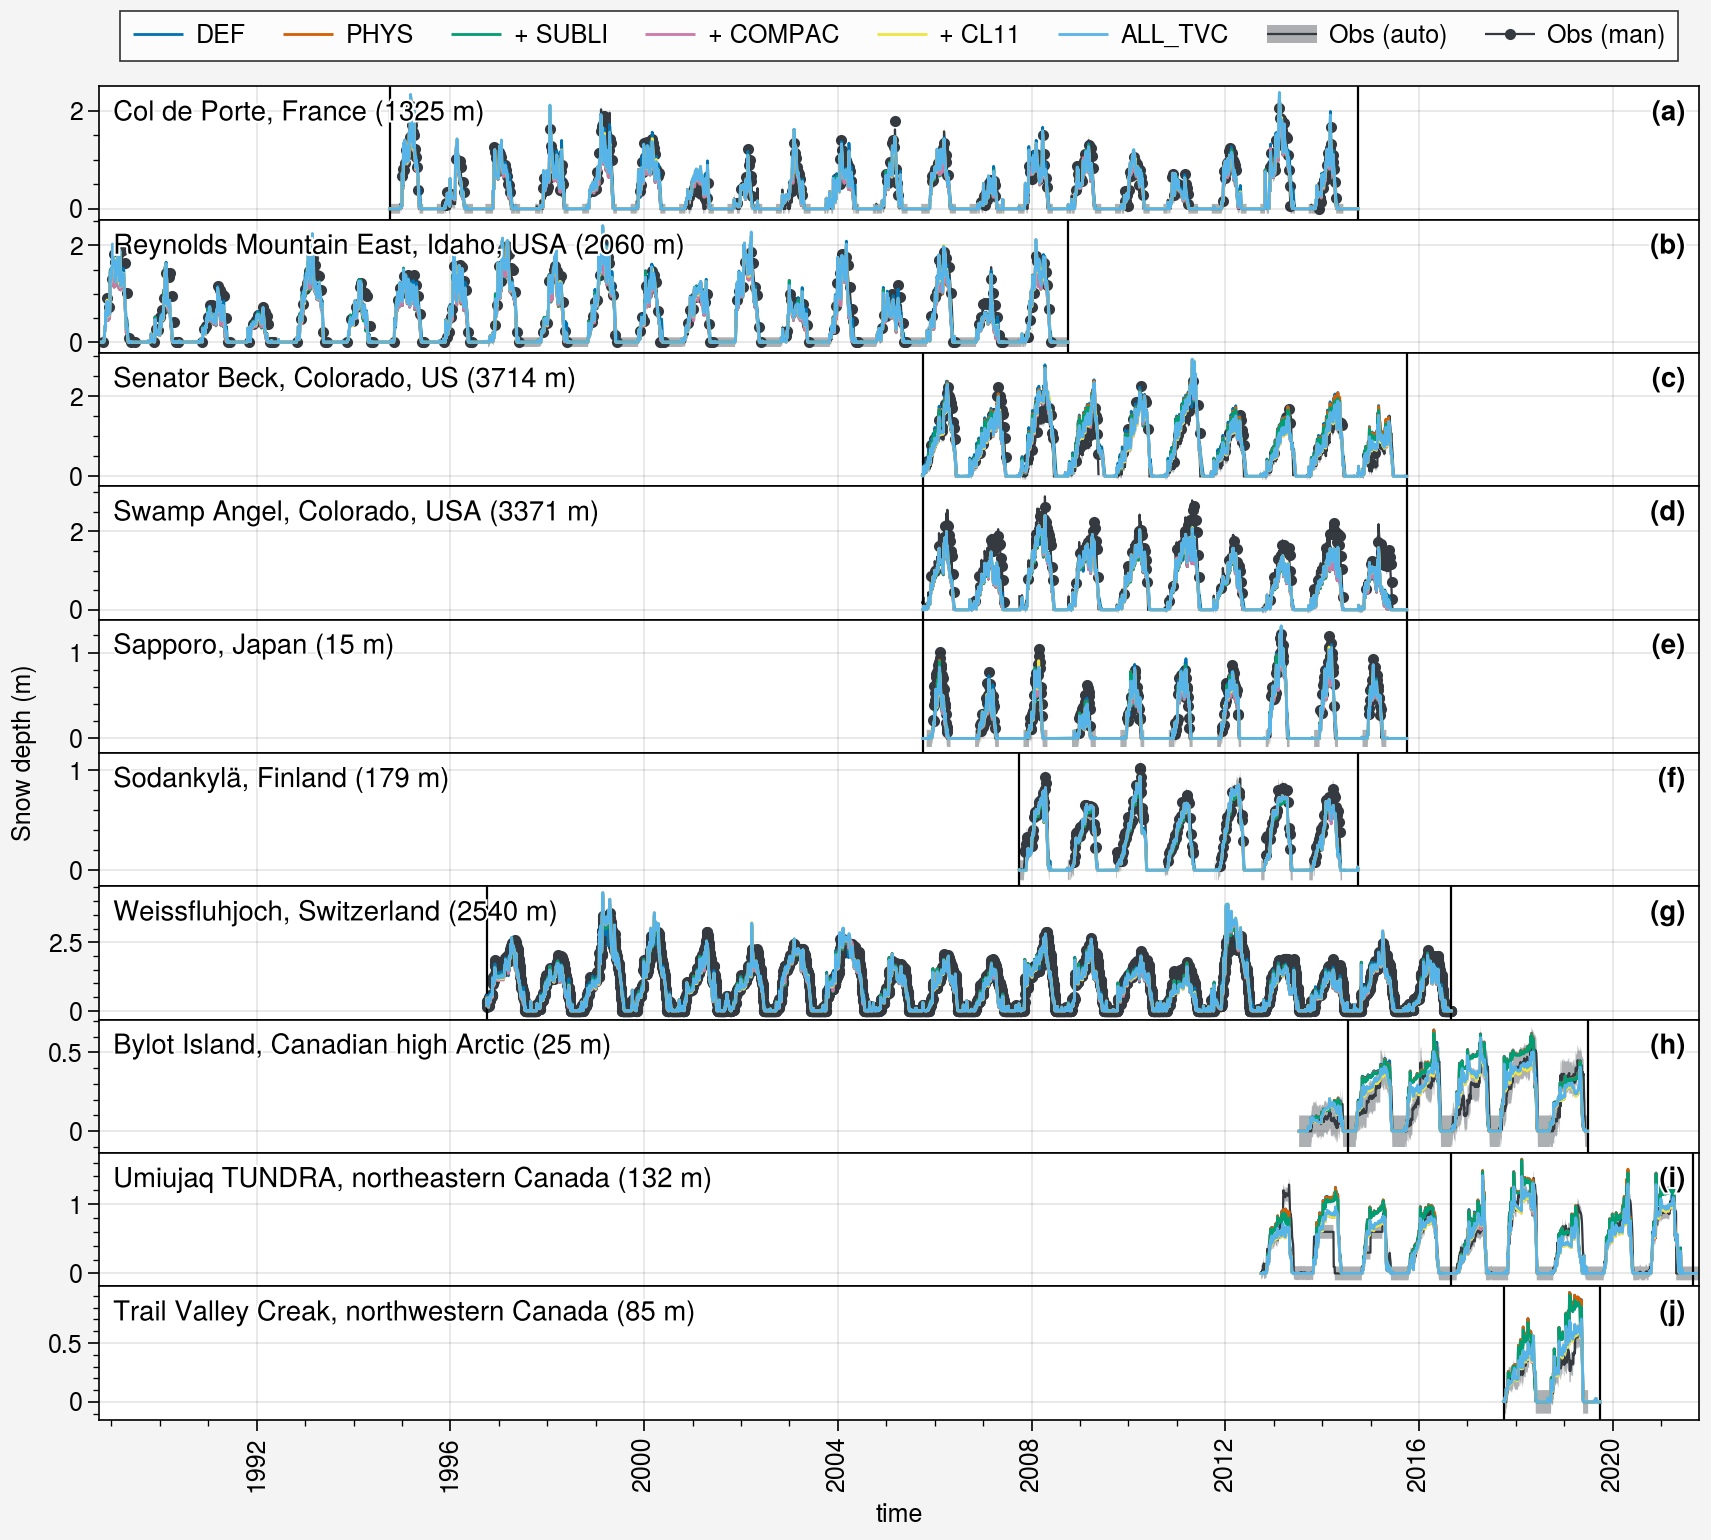

In [13]:
fig, axs = pplt.subplots(nrows=len(SnowMIP_sites+SnowArctic_sites), refaspect=12, refwidth=8, space=0)

color_obs = 'gray8'

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    # Model 
    h_exps = []
    # for j, exp in enumerate(exps): 
    for j, exp in enumerate(label_exps): 
        h = axs[i].plot(ds_d_SnowMIP_list[j][i].snd.sel(time=slice(site.start, site.stop)), label=exp, lw=1)
        h_exps.append(h)

    # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
    #     h_paul = axs[i].plot(ds_d_Paul_list[i].snd.sel(time=slice(site.start, site.stop)), label='CLASS', color='red9', lw=1)
    
    # Obs
    shadedata = np.concatenate((
        np.expand_dims(ds_d_Obs_list[i].snd_auto.sel(time=slice(site.start, site.stop)).values+0.1, axis=0),
        np.expand_dims(ds_d_Obs_list[i].snd_auto.sel(time=slice(site.start, site.stop)).values-0.1, axis=0),), axis=0)
    h_obs_auto = axs[i].plot(ds_d_Obs_list[i].snd_auto.sel(time=slice(site.start, site.stop)), shadedata=shadedata, color=color_obs, 
                zorder=0, lw=0.8, label='Obs (auto)')
    
    if 'snd_man' in list(ds_d_Obs_list[i].keys()):
        h_obs_man = axs[i].plot(ds_d_Obs_list[i].snd_man.sel(time=slice(site.start, site.stop)), marker='.', color=color_obs, 
                    zorder=0, lw=0.8, label='Obs (man)')
    
    axs[i].format(ylabel='Snow depth (m)', ultitle=site.long_name+' ('+site.elevation+')')
    axs[i].vlines(ds_d_SnowMIP_list[j][i].sel(time=site.period_used).time[0], axs[i].get_ylim()[0], axs[i].get_ylim()[1], 
                  color='k', lw=0.8)
    axs[i].vlines(ds_d_SnowMIP_list[j][i].sel(time=site.period_used).time[-1], axs[i].get_ylim()[0], axs[i].get_ylim()[1], 
                  color='k', lw=0.8)
    


# axs[4].legend(ncols=5, loc='ll')
# fig.legend(h_exps+h_paul+h_obs_auto+h_obs_man, ncols=2, loc='t')
fig.legend(h_exps+h_obs_auto+h_obs_man, ncols=8, loc='t')

fig.format(abc='(a)', abcloc='ur')

# fig.suptitle('Col de Porte, France, 1325 m')
# fig.save('img/tn1_sd_correct_SH.jpg')

### Annual cycles

In [14]:
[site.name for site in SnowMIP_sites+SnowArctic_sites]

['cdp', 'rme', 'snb', 'swa', 'sap', 'sod', 'wfj', 'byl', 'umt', 'tvc']

In [15]:
label_exps[:]

['DEF', 'PHYS', '+ SUBLI', '+ COMPAC', '+ CL11', 'ALL_TVC']

In [16]:
def fill_snowdepth_gaps(da, long_gap_days=50):
    """
    Fill snow-depth time series:
    - NaN gaps <= long_gap_days: linear interpolation
    - NaN gaps > long_gap_days: set to 0
    
    Intended for plotting seasonal cycles, not necessarily for metrics.
    """
    s = da.to_series().copy()
    is_nan = s.isna()

    # Identify consecutive NaN / non-NaN runs
    run_id = (is_nan != is_nan.shift(fill_value=False)).cumsum()

    s_filled = s.copy()

    for _, idx in s[is_nan].groupby(run_id[is_nan]).groups.items():
        gap_len = len(idx)

        if gap_len > long_gap_days:
            # Long summer-like missing period -> assume snow-free
            s_filled.loc[idx] = 0.0

    # Remaining shorter NaN gaps -> linear interpolation
    s_filled = s_filled.interpolate(method="time", limit_area="inside")

    return xr.DataArray(
        s_filled,
        dims=da.dims,
        coords=da.coords,
        attrs=da.attrs,
        name=da.name
    )

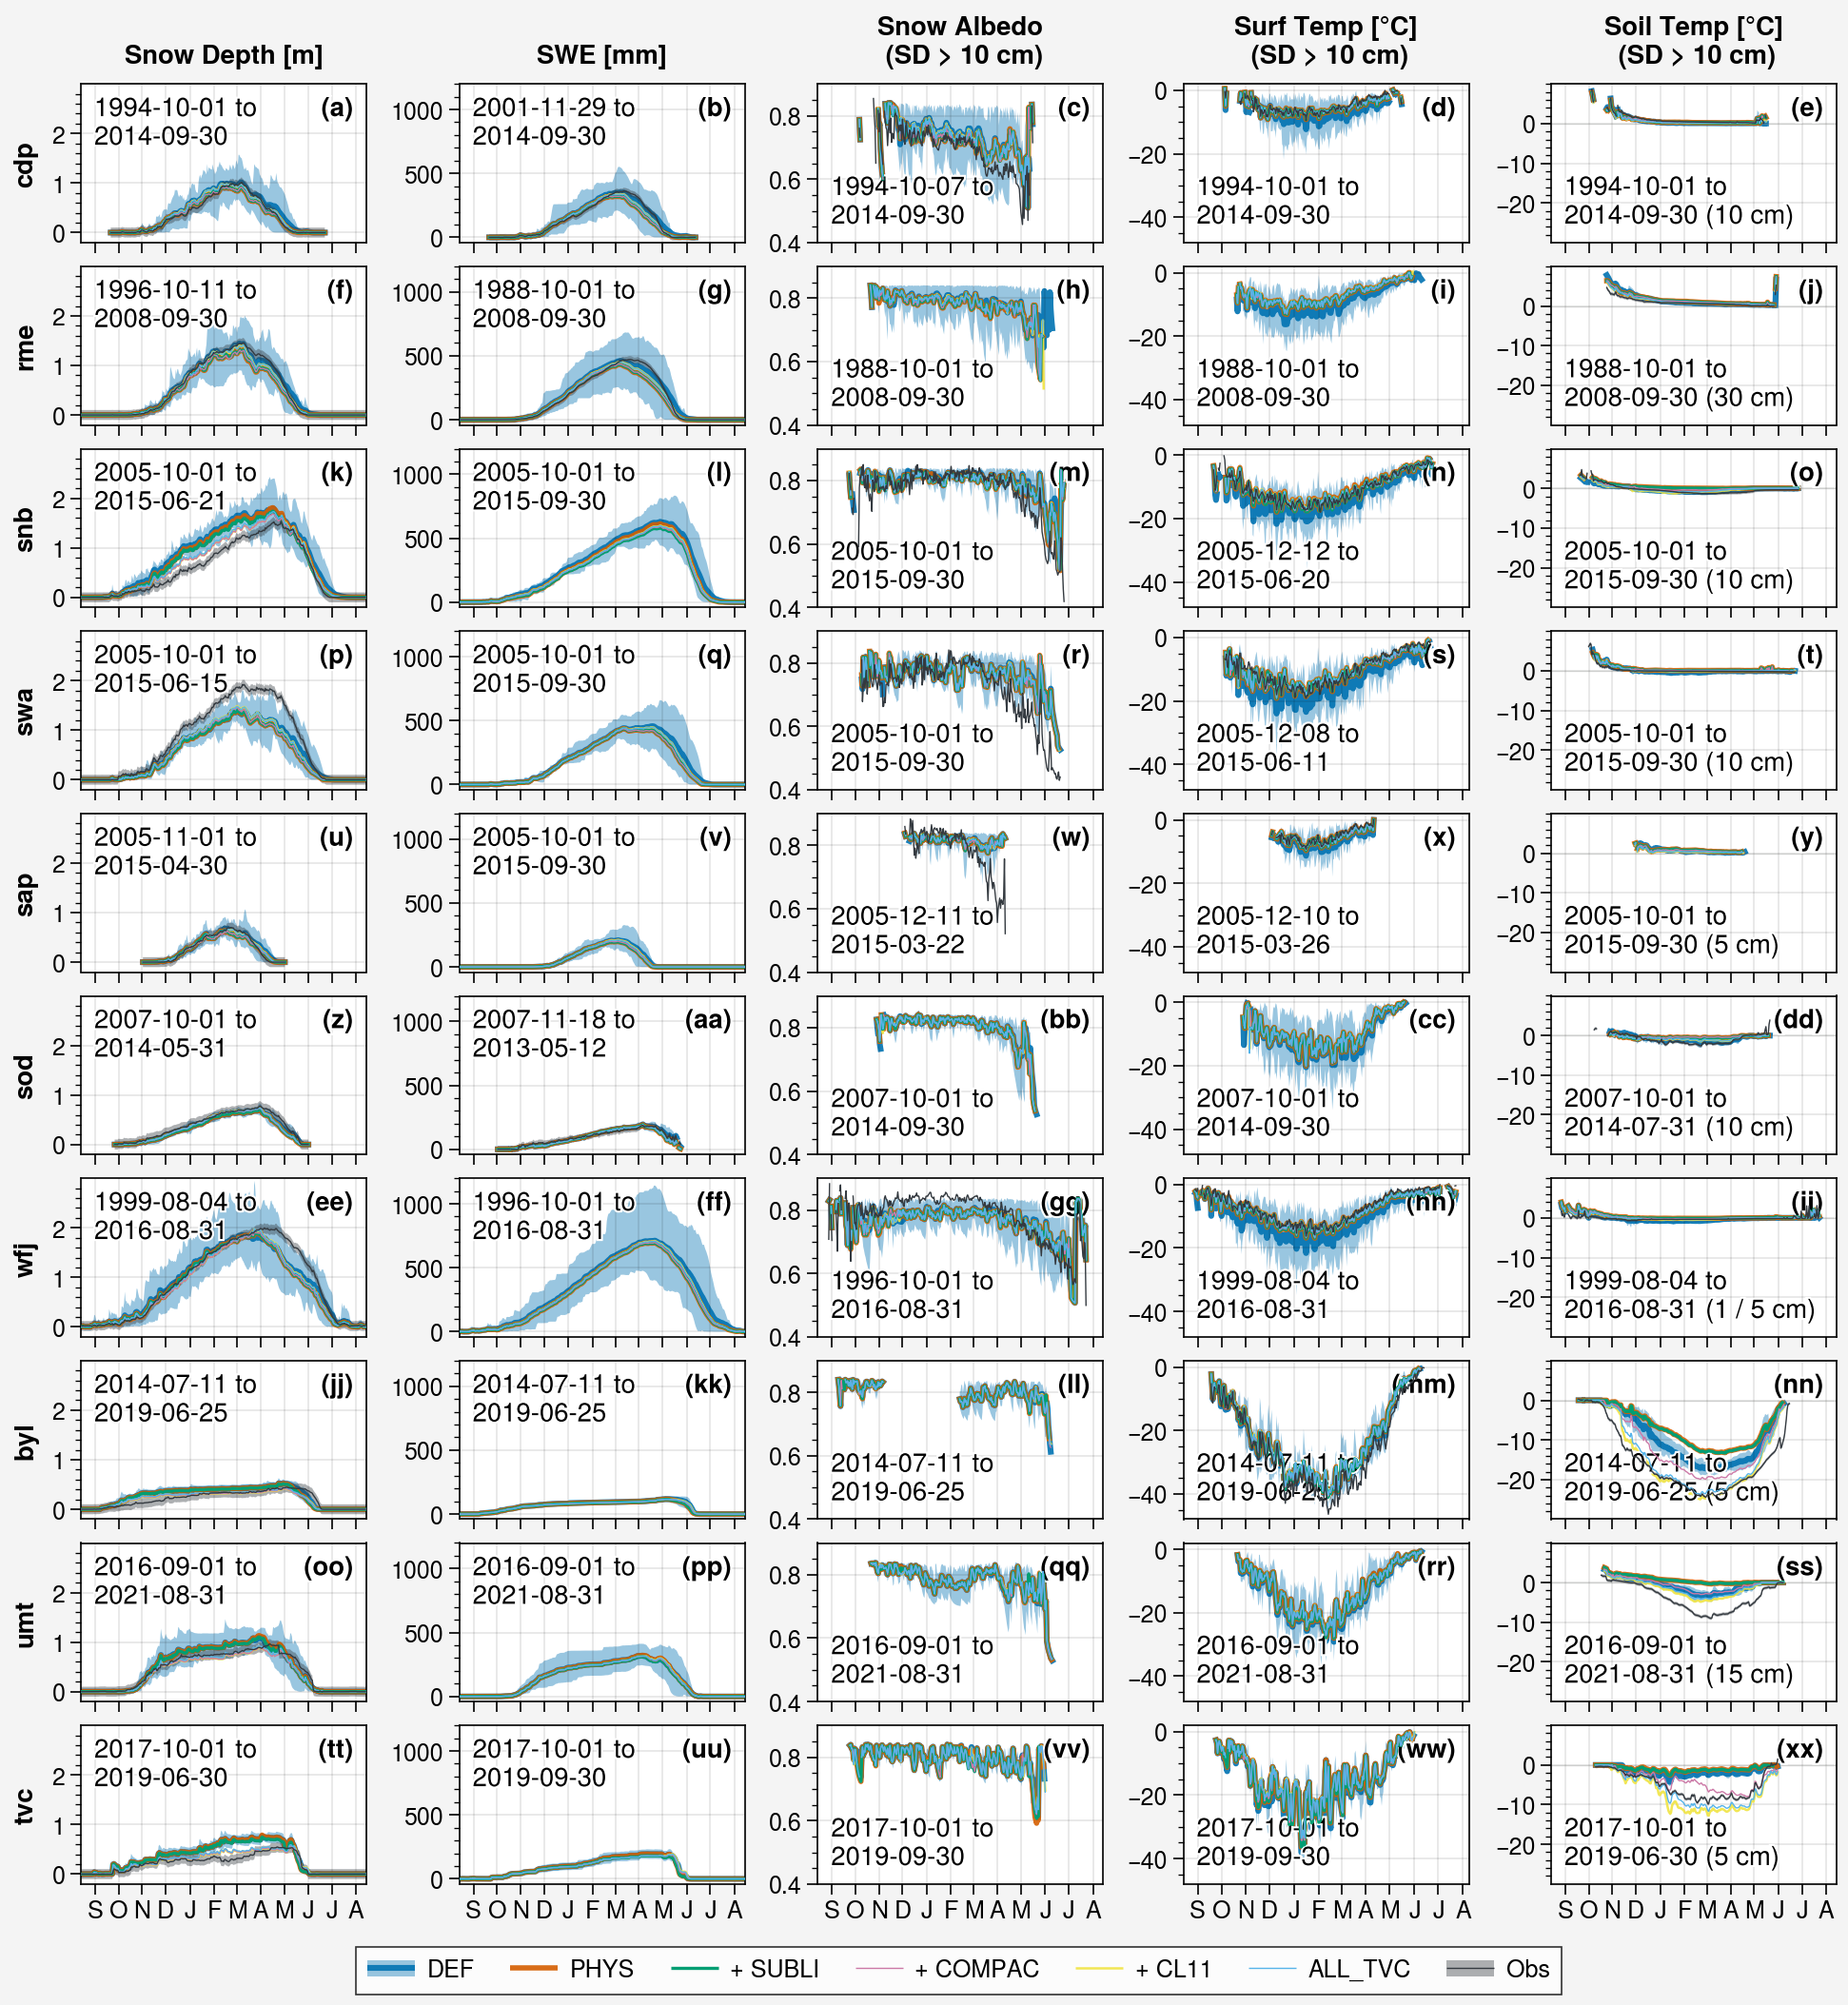

In [17]:
import warnings
warnings.filterwarnings("ignore")

color_obs = 'gray8'

# Shifted DOY tick positions (non-leap year, shift = -140)
# These are the first DOY of each corresponding month in the shifted calendar
xticks = [
    19,   # Sep
    49,   # Oct
    79,   # Nov
    109,  # Dec
    140,  # Jan
    171,  # Feb
    200,  # Mar
    230,  # Apr
    260,  # May
    291,  # Jun
    321,  # Jul
    352   # Aug (closing)
]

# Corresponding month initials
xlabels = ['S', 'O', 'N', 'D', 'J', 'F', 'M', 'A', 'M', 'J', 'J', 'A']


# -------------------------------------------------------------------
# Styles (ONLY addition)
# -------------------------------------------------------------------
lw_def,    zorder_def,    alpha_def    = 2.2,  1,  0.9   # blue
lw_phys,   zorder_phys,   alpha_phys   = 2.0,  2,  0.9   # orange
lw_subli,  zorder_subli,  alpha_subli  = 1.2,  8,  1.0   # green
lw_compac, zorder_compac, alpha_compac = 0.5,  9,  1.0   # pink
lw_cl11,   zorder_cl11,   alpha_cl11   = 0.9,  2,  0.9   # yellow
lw_tvc,    zorder_tvc,    alpha_tvc    = 0.5, 10,  1.0   # light blue

def style(exp):
    if exp == 'PHYS':
        return dict(lw=lw_phys,   zorder=zorder_phys,   alpha=alpha_phys)
    elif exp == '+ SUBLI':
        return dict(lw=lw_subli,  zorder=zorder_subli,  alpha=alpha_subli)
    elif exp == '+ COMPAC':
        return dict(lw=lw_compac, zorder=zorder_compac, alpha=alpha_compac)
    elif exp == '+ CL11':
        return dict(lw=lw_cl11,   zorder=zorder_cl11,   alpha=alpha_cl11)
    elif exp == 'ALL_TVC':
        return dict(lw=lw_tvc,    zorder=zorder_tvc,    alpha=alpha_tvc)
    else:
        return dict(lw=0.5, zorder=5, alpha=1.0)


# fig, axs = pplt.subplots(ncols=5, nrows=len(SnowMIP_sites+SnowArctic_sites), refwidth=1.5, sharey=0)
fig, axs = pplt.subplots(ncols=5, nrows=len(SnowMIP_sites+SnowArctic_sites), refwidth=1.5, sharey=0, hspace=1, refaspect=1.8)

# for i, site in enumerate([cdp]):
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):

    doy = 140
    period = site.period_used

    # Snow depth
    ax = axs[i*5+0]
    if site.name in ['snb', 'swa']:
        # Fill snow depth gaps for better visualization of seasonal cycle (intended for plotting, not necessarily for metrics)
        # Works only for snd_auto covering the whole period, which is the case for these 2 sites
        snd_obs_filled = fill_snowdepth_gaps(ds_d_Obs_list[i].snd_auto, long_gap_days=50)
    else:
        snd_obs_filled = ds_d_Obs_list[i].snd_auto
    mask_obs = ~snd_obs_filled.sel(time=period).isnull()

    shadedata = ds_d_SnowMIP_list[0][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
    h1 = ax.plot(ds_d_SnowMIP_list[0][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                 .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                 shadedata=shadedata, label=label_exps[0],
                 zorder=zorder_def, lw=lw_def, alpha=alpha_def)

    h_exps = []
    for j, exp in enumerate(label_exps[1:]):
        st = style(exp)
        h = ax.plot(ds_d_SnowMIP_list[j+1][i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                 .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                 label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
        h_exps.append(h)

    # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
    #     h_paul = ax.plot(ds_d_Paul_list[i].snd.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
    #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

    obs = snd_obs_filled.sel(time=period).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
    shadedata = np.concatenate((np.expand_dims(obs.values+0.1, axis=0), np.expand_dims(obs.values-0.1, axis=0),), axis=0)
    h_obs = ax.plot(obs, shadedata=shadedata, label='Obs', color=color_obs, lw=0.5, zorder=10)
    ax.format(ylabel='', xlabel='', ylim=(-0.2,3), yticks=[0, 1, 2],
              ultitle=str(ds_d_Obs_list[i].sel(time=period).snd_auto.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
              str(ds_d_Obs_list[i].sel(time=period).snd_auto.dropna(dim='time').time[-1].values)[:10],
              xticks=xticks, xticklabels=xlabels, xtickminor=False)
    # ax.legend(h1+h_exps+h_paul+h_obs, loc='ul', ncols=1)

    # Snow Water Equivalent
    ax = axs[i*5+1]

    if 'snw_auto' in list(ds_d_Obs_list[i].keys()):
        mask_obs = ~ds_d_Obs_list[i].snw_auto.sel(time=period).isnull()

        shadedata = ds_d_SnowMIP_list[0][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].snw.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
        #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

        obs = ds_d_Obs_list[i].snw_auto.sel(time=period).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        shadedata = np.concatenate((np.expand_dims(obs.values+25, axis=0), np.expand_dims(obs.values-25, axis=0),), axis=0)
        h_obs = ax.plot(obs, shadedata=shadedata, label='Obs', color=color_obs, lw=0.5, zorder=10)
        ax.format(ylabel='', ylim=(-40,1200),
                  ultitle=str(ds_d_Obs_list[i].sel(time=period).snw_auto.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                  str(ds_d_Obs_list[i].sel(time=period).snw_auto.dropna(dim='time').time[-1].values)[:10])

    else:
        shadedata = ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].snw.sel(time=period).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].snw.sel(time=period).groupby('time.dayofyear').mean()\
        #                  .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.format(ylabel='', xlabel='', ylim=(-40,1200), ultitle=period.start+' to\n'+ period.stop, xticks=xticks, xticklabels=xlabels, xtickminor=False)


    # Albedo (need to add a condition albsn > 0.4 because a few values are 0 in the model -> bug? (e.g., at Saporo)
    # + low values are observed in the begining of the season (probably due to not full SCF coveraged)
    ax = axs[i*5+2]
    lim_alb = 0.4
    lim_alb_sup = 0.9

    if 'albs' in list(ds_d_Obs_list[i].keys()):
        mask_obs = ~ds_d_Obs_list[i].albs.where(ds_d_Obs_list[i].albs > lim_alb).where(ds_d_Obs_list[i].albs < lim_alb_sup)\
                    .where(ds_d_Obs_list[i].snd_auto > 0.1).sel(time=period).isnull()

        shadedata = ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                    .where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                     .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                     .where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].albsn > lim_alb) \
                        .where(ds_d_SnowMIP_list[j+1][i].albsn < lim_alb_sup)\
                        .where(ds_d_SnowMIP_list[j+1][i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
                        .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].albsn.sel(time=period).where(ds_d_Paul_list[i].albsn > lim_alb) \
        #                     .where(ds_d_Paul_list[i].albsn < lim_alb_sup)\
        #                     .where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs).groupby('time.dayofyear').mean()\
        #                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)
        if site not in ['umt', 'byl']:
            obs = ds_d_Obs_list[i].albs.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
            h_obs = ax.plot(obs, label='Obs', color=color_obs, lw=0.5, zorder=10)
            ax.format(ylabel='', ylim=(0.4,0.9),
                      lltitle=str(ds_d_Obs_list[i].sel(time=period).albs.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].sel(time=period).albs.dropna(dim='time').time[-1].values)[:10])

    else:
        shadedata = ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                    .where(ds_d_SnowMIP_list[0][i].snd > 0.1).groupby('time.dayofyear').quantile([0.1, 0.9])\
                    .sel(dayofyear=slice(1,365)).roll(dayofyear=doy).transpose('quantile', 'dayofyear')
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[0][i].albsn > lim_alb) \
                    .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
                     .where(ds_d_SnowMIP_list[0][i].snd > 0.1).groupby('time.dayofyear').mean()\
                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].albsn.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].albsn > lim_alb) \
                        .where(ds_d_SnowMIP_list[j+1][i].albsn < lim_alb_sup)\
                        .where(ds_d_SnowMIP_list[j+1][i].snd > 0.1).groupby('time.dayofyear').mean()\
                        .sel(dayofyear=slice(1,365)).roll(dayofyear=doy),
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].albsn.sel(time=period).where(ds_d_Paul_list[i].albsn > lim_alb) \
        #                      .where(ds_d_SnowMIP_list[0][i].albsn < lim_alb_sup)\
        #                     .where(ds_d_Paul_list[i].snd > 0.1).groupby('time.dayofyear').mean()\
        #                     .sel(dayofyear=slice(1,365)).roll(dayofyear=doy), label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.format(ylabel='', xlabel='', ylim=(0.4,0.9), lltitle=period.start+' to\n'+ period.stop, xticks=xticks, xticklabels=xlabels, xtickminor=False)


    # Surface temperature
    # Add condition on ts <= 0 on obs to avoid melting pachy areas to be counted
    ax = axs[i*5+3]

    if 'ts' in list(ds_d_Obs_list[i].keys()) and ds_d_Obs_list[i].ts.notnull().sum() != 0:
        mask_obs = ~ds_d_Obs_list[i].ts.sel(time=period).where(ds_d_Obs_list[i].ts <= 0)\
                    .where(ds_d_Obs_list[i].snd_auto > 0.1).isnull()

        shadedata = ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].ts.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .where(mask_obs).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].ts.sel(time=period).where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        obs = ds_d_Obs_list[i].ts.sel(time=period).where(mask_obs).groupby('time.dayofyear').mean()\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        h_obs = ax.plot(obs, label='Obs', color=color_obs, lw=0.5, zorder=10)
        ax.format(ylabel='', ylim=(-48,2),
                  lltitle=str(ds_d_Obs_list[i].sel(time=period).ts.dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                  str(ds_d_Obs_list[i].sel(time=period).ts.dropna(dim='time').time[-1].values)[:10])

    else:
        shadedata = ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].ts.sel(time=period).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].ts.sel(time=period).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     h_paul = ax.plot(ds_d_Paul_list[i].ts.sel(time=period).where(ds_d_Paul_list[i].snd > 0.1)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.format(ylabel='', xlabel='', ylim=(-48,2), lltitle=period.start+' to\n'+ period.stop, xticks=xticks, xticklabels=xlabels, xtickminor=False)


    # Soil temperature
    ax = axs[i*5+4]

    if 'tsl' in list(ds_d_Obs_list[i].keys()):

        # Get the first soil layer from obs (except for byl)
        if site.name in ['byl', 'tvc']:
            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[1].values.item(0) # 0.05 instead of 0.02
        else:
            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[0].values.item(0)

        # For wfj (otherwise NaN so take the first model level)
        if obs_sdepth < 0.01:
            model_sdepth = 0.05
        else:
            model_sdepth = obs_sdepth
        mask_obs = ~ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).where(ds_d_Obs_list[i].snd_auto > 0.1).isnull()

        # Interp model on the first soil layer obs
        if obs_sdepth < 0.01:
            ds_d_interp = ds_d_SnowMIP_list[0][i]
        else:
            ds_d_interp = ds_d_SnowMIP_list[0][i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)

        shadedata = ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1).where(mask_obs)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            if obs_sdepth < 0.01:
                ds_d_interp = ds_d_SnowMIP_list[j+1][i]
            else:
                ds_d_interp = ds_d_SnowMIP_list[j+1][i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)

            st = style(exp)
            h = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .where(mask_obs).groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     if obs_sdepth < 0.01:
        #         ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_SnowMIP_list[0][i].tsl.layer.values)
        #     else:
        #         ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
        #     h_paul = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_Paul_list[i].snd > 0.1).where(mask_obs)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        obs = ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).where(mask_obs).groupby('time.dayofyear').mean()\
                .sel(dayofyear=slice(1,365)).roll(dayofyear=doy)
        shadedata = np.concatenate((np.expand_dims(obs.values+0.4, axis=0), np.expand_dims(obs.values-0.4, axis=0),), axis=0)
        h_obs = ax.plot(obs, label='Obs', shadedata=shadedata, color=color_obs, lw=0.5, zorder=10)
        ax.hlines(0, 1, 365, c='gray', lw=0.5, alpha=0.3)
        if site.name == 'byl':
            ylim=(-30, 10)
        else:
            ylim=(-30, 10)
            # ylim=(-5, 10)
        if obs_sdepth != model_sdepth:
            ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20],
                      lltitle=str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[-1].values)[:10]+' ('+\
                         str(round(obs_sdepth*100))+' / '+str(round(model_sdepth*100))+' cm)')
        else:
            ax.format(ylabel='', ylim=ylim, yticks=[0, -10, -20],
                      lltitle=str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[0].values)[:10]+' to\n'+ \
                      str(ds_d_Obs_list[i].tsl.sel(time=period, sdepth=obs_sdepth).dropna(dim='time').time[-1].values)[:10]+' ('+\
                         str(round(obs_sdepth*100))+' cm)')

    else:
        model_sdepth = 0.05 # first level

        shadedata = ds_d_SnowMIP_list[0][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                    .groupby('time.dayofyear').quantile([0.1, 0.9]).sel(dayofyear=slice(1,365)).roll(dayofyear=doy)\
                    .transpose('quantile', 'dayofyear')-273.15
        h1 = ax.plot(ds_d_SnowMIP_list[0][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[0][i].snd > 0.1)\
                     .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                     .roll(dayofyear=doy)-273.15,
                     shadedata=shadedata, label=label_exps[0],
                     zorder=zorder_def, lw=lw_def, alpha=alpha_def)

        h_exps = []
        for j, exp in enumerate(label_exps[1:]):
            st = style(exp)
            h = ax.plot(ds_d_SnowMIP_list[j+1][i].tsl.sel(time=period, layer=model_sdepth).where(ds_d_SnowMIP_list[j+1][i].snd > 0.1)\
                        .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
                        .roll(dayofyear=doy)-273.15,
                        label=exp, lw=st['lw'], zorder=st['zorder'], alpha=st['alpha'])
            h_exps.append(h)

        # if site.name in [site_SnowMIP.name for site_SnowMIP in SnowMIP_sites]:
        #     ds_d_interp = ds_d_Paul_list[i].interp(layer=ds_d_SnowMIP_list[0][i].tsl.layer.values)
        #     h_paul = ax.plot(ds_d_interp.tsl.sel(time=period, layer=model_sdepth).where(ds_d_Paul_list[i].snd > 0.1)\
        #                      .groupby('time.dayofyear').mean().sel(dayofyear=slice(1,365))\
        #                      .roll(dayofyear=doy)-273.15, label='CLASS', color='red9', zorder=9, lw=0.5)

        ax.hlines(0, 1, 365, c='gray', lw=0.5, alpha=0.3)
        ax.format(ylabel='', xlabel='', ylim=ylim, yticks=[0, -10, -20], lltitle=period.start+' to\n'+ period.stop+' ('+\
                     str(round(model_sdepth*100))+' cm)', xticks=xticks, xticklabels=xlabels, xtickminor=False)


for ax in axs:
    ax.format(xlabel='')

fig.format(abc='(a)', abcloc='ur',
           collabels=['Snow Depth [m]', 'SWE [mm]', 'Snow Albedo\n (SD > 10 cm)', 'Surf Temp [°C]\n (SD > 10 cm)',
                      'Soil Temp [°C]\n (SD > 10 cm)'],
           rowlabels=[site.name for site in SnowMIP_sites+SnowArctic_sites])
# fig.legend(h1+h_exps+h_paul+h_obs, loc='b', ncols=2)
fig.legend(h1+h_exps+h_obs, loc='b', ncols=8)

# fig.save('img/paper_ac_all_v4_correct_SH.jpg')
# fig.save('img/paper_ac_all_v4_correct_SH.png')
# fig.save('img/paper_ac_all_v4_correct_SH.pdf')


## Metrics

## Time series

In [18]:
def mb(simu, obs):
    return (simu-obs).mean().values.item(0)

def rmb(simu, obs):
    return ((simu-obs).mean()/np.abs(obs.mean())).values.item(0)*100
    
def mab(simu, obs):
    return (np.abs(simu-obs)).mean().values.item(0)

def rmab(simu, obs):
    return ((np.abs(simu-obs)).mean()/np.abs(obs.mean())).values.item(0)*100
    
def rmse(simu, obs):
    return np.sqrt(((simu-obs)**2).mean()).values.item(0)

def rrmse(simu, obs):
    return (np.sqrt(((simu-obs)**2).mean())/np.abs(obs.mean())).values.item(0)*100
    
def corr(simu, obs):
    return xr.corr(simu, obs).values.item(0)

In [19]:
def mb_a(simu, obs):
    return (simu-obs).mean()

def rmb_a(simu, obs):
    return ((simu-obs).mean()/np.abs(obs.mean()))*100
    
def mab_a(simu, obs):
    return (np.abs(simu-obs)).mean()

def rmab_a(simu, obs):
    return ((np.abs(simu-obs)).mean()/np.abs(obs.mean()))*100
    
def rmse_a(simu, obs):
    return np.sqrt(((simu-obs)**2).mean())

def rrmse_a(simu, obs):
    return (np.sqrt(((simu-obs)**2).mean())/np.abs(obs.mean()))*100
    
def corr_a(simu, obs):
    r, _ = stats.pearsonr(simu, obs)
    return r

In [20]:
# Can be negative if rmse > std
def calculate_score(std_deviation, rmse):
    return (std_deviation - rmse) / std_deviation

In [21]:
['Obs'] + [site.name for site in SnowMIP_sites]

['Obs', 'cdp', 'rme', 'snb', 'swa', 'sap', 'sod', 'wfj']

In [22]:
exps

['DEF',
 'BUG_CORRECT_TSNBT_OP1_EZERO',
 'PHYS_ALL_SUBLI_v2',
 'PHYS_ALL_SUBLI_v2_COMPAC_v1',
 'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne',
 'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne']

In [23]:
df_metrics_list = []
column_indexes = ['mb', 'rmb', 'nmb', 'mab', 'rmab', 'rmse', 'rrmse', 'nrmse', 'r', 'stdd', 'score']

for site in SnowMIP_sites+SnowArctic_sites:
    row_indexes = [['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'tsn', 'SCD'], 
                   # ['Obs', 'CLASS']+exps]
                   ['Obs']+exps]
    rows = pd.MultiIndex.from_product(row_indexes)
    
    df_metrics = pd.DataFrame(index=rows, columns=column_indexes)
    df_metrics_list.append(df_metrics)
    
df_metrics_list[0]

mb  rmb  nmb  mab  \
snd_auto Obs                                           NaN  NaN  NaN  NaN   
         DEF                                           NaN  NaN  NaN  NaN   
         BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2                             NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN  NaN  NaN   
...                                                    ...  ...  ...  ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2                             NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           NaN  NaN  NaN  NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  NaN  NaN  NaN  NaN   

                                                      rmab rmse rrmse nrmse  \
snd_auto Obs                                           NaN  NaN   NaN   NaN   
         DEF                                           NaN  NaN   NaN   NaN   
         BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2                             NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN   NaN   NaN   
...                                                    ...  ...   ...   ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2                             NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           NaN  NaN   NaN   NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  NaN  NaN   NaN   NaN   

                                                         r stdd score  
snd_auto Obs                                           NaN  NaN   NaN  
         DEF                                           NaN  NaN   NaN  
         BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2                             NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN   NaN  
...                                                    ...  ...   ...  
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                   NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2                             NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           NaN  NaN   NaN  
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  NaN  NaN   NaN  

[63 rows x 11 columns]

In [24]:
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    period = site.period_used
    for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl']:

        arr1 = ['Obs']+exps
        arr2 = [ds_d_Obs_list[i]]+[ds_d_SnowMIP_list[j][i] for j in range(len(exps))]
            
        for exp, ds_simu in zip(arr1, arr2):

            # We are going to make a common mask based on snd_auto so the comparison will be on the same period (auto/man)
            mask_obs_snd = ~ds_d_Obs_list[i].snd_auto.where(ds_d_Obs_list[i].snd_auto > 0.1).sel(time=period).isnull()
            if exp == 'Obs':
                if var == 'snd_auto':
                    obs = ds_d_Obs_list[i].snd_auto.where(mask_obs_snd).sel(time=period)
                    simu = obs
                elif var == 'snd_man':
                    if 'snd_man' in list(ds_d_Obs_list[i].keys()):
                        mask_obs = ~ds_d_Obs_list[i].snd_man.where(ds_d_Obs_list[i].snd_man > 0.1).sel(time=period).isnull()
                        obs = ds_d_Obs_list[i].snd_man.where(mask_obs_snd).where(mask_obs).sel(time=period)
                        simu = obs
                    else:
                        pass
                elif var == 'snw_auto':
                    if 'snw_auto' in list(ds_d_Obs_list[i].keys()):
                        obs = ds_d_Obs_list[i].snw_auto.where(mask_obs_snd).sel(time=period)
                        simu = obs
                    else:
                        pass
                elif var == 'snw_man':
                    if 'snw_man' in list(ds_d_Obs_list[i].keys()):
                        obs = ds_d_Obs_list[i].snw_man.where(mask_obs_snd).sel(time=period)
                        simu = obs
                    else:
                        pass
                elif var == 'albs':
                    if 'albs' in list(ds_d_Obs_list[i].keys()):
                        mask_obs = ~ds_d_Obs_list[i].albs.where(ds_d_Obs_list[i].albs > 0.4)\
                                    .where(ds_d_Obs_list[i].albs < 0.9).sel(time=period).isnull()
                        obs = ds_d_Obs_list[i].albs.where(mask_obs_snd).where(mask_obs).sel(time=period)
                        simu = obs
                    else:
                        pass
                elif var == 'ts':
                    if 'ts' in list(ds_d_Obs_list[i].keys()):
                        mask_obs = ~ds_d_Obs_list[i].ts.where(ds_d_Obs_list[i].ts <= 0).sel(time=period).isnull()
                        obs = ds_d_Obs_list[i].ts.where(mask_obs_snd).where(mask_obs).sel(time=period)
                        simu = obs
                    else:
                        pass
                elif var == 'tsl':
                    if 'tsl' in list(ds_d_Obs_list[i].keys()):
                        # Get the first soil layer from obs
                        if site.name in ['byl', 'tvc']:
                            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[1].values.item(0)
                        else:
                            obs_sdepth = ds_d_Obs_list[i].tsl.sdepth[0].values.item(0) 
                        obs = ds_d_Obs_list[i].tsl.where(mask_obs_snd).sel(time=period, sdepth=obs_sdepth)
                        simu = obs
                    else:
                        pass
                else:
                    raise ValueError(var+" is not supported.")
                    
            # Model
            else:
                mask_simu_snd = ~ds_simu.snd.where(ds_simu.snd > 0.1).sel(time=period).isnull()
                if var in ['snd_auto', 'snd_man']:
                    simu = ds_simu.snd.where(obs.notnull()).where(mask_simu_snd).sel(time=period)
                elif var in ['snw_auto', 'snw_man']:
                    simu = ds_simu.snw.where(obs.notnull()).where(mask_simu_snd).sel(time=period)
                elif var == 'albs':
                    simu = ds_simu['albsn'].where(ds_simu.albsn > 0.4).where(ds_simu.albsn < 0.9).where(obs.notnull())\
                            .where(mask_simu_snd).sel(time=period)
                elif var == 'ts':
                    simu = ds_simu[var].where(obs.notnull()).where(mask_simu_snd).sel(time=period)-273.15
                elif var == 'tsl':
                    if 'tsl' in list(ds_d_Obs_list[i].keys()):
                        # Interp model on the first soil layer obs
                        if obs_sdepth < 0.01: 
                            ds_d_interp = ds_simu[var]
                            model_sdepth = 0.05
                        else:
                            ds_d_interp = ds_simu[var].interp(layer=ds_d_Obs_list[i].tsl.sdepth.values)
                            model_sdepth = obs_sdepth
                        simu = ds_d_interp.where(obs.notnull()).where(mask_simu_snd).sel(time=period, layer=model_sdepth)-273.15
                    else:
                        pass
                else:
                    raise ValueError(var+" is not supported.")

            if var in list(ds_d_Obs_list[i].keys()):
                # Remove albedo for Arctic sites because suspect wrong values
                if not (site.name in ['byl', 'umt', 'umf'] and var == 'albs'):
                    df_metrics_list[i].loc[(var, exp), 'mb'] = mb(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'rmb'] = rmb(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'nmb'] = mb(simu, obs)/obs.std().values.item(0)
                    df_metrics_list[i].loc[(var, exp), 'mab'] = mab(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'rmab'] = rmab(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'rmse'] = rmse(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'rrmse'] = rrmse(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'nrmse'] = rmse(simu, obs)/obs.std().values.item(0)
                    df_metrics_list[i].loc[(var, exp), 'r'] = corr(simu, obs)
                    df_metrics_list[i].loc[(var, exp), 'stdd'] = simu.std().values.item(0)
                    df_metrics_list[i].loc[(var, exp), 'score'] = calculate_score(obs.std().values.item(0), rmse(simu, obs))

            
df_metrics_list[0]

mb       rmb  \
snd_auto Obs                                                0.0       0.0   
         DEF                                           0.056881  8.227255   
         BUG_CORRECT_TSNBT_OP1_EZERO                  -0.022213 -3.212943   
         PHYS_ALL_SUBLI_v2                            -0.022517 -3.256914   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.023873 -3.452994   
...                                                         ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                        NaN       NaN   
         PHYS_ALL_SUBLI_v2                                  NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                        NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne       NaN       NaN   

                                                            nmb       mab  \
snd_auto Obs                                                0.0       0.0   
         DEF                                            0.14453  0.141662   
         BUG_CORRECT_TSNBT_OP1_EZERO                  -0.056442  0.140857   
         PHYS_ALL_SUBLI_v2                            -0.057215  0.140615   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.060659  0.141254   
...                                                         ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                        NaN       NaN   
         PHYS_ALL_SUBLI_v2                                  NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                        NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne       NaN       NaN   

                                                            rmab      rmse  \
snd_auto Obs                                                 0.0       0.0   
         DEF                                           20.489998  0.183213   
         BUG_CORRECT_TSNBT_OP1_EZERO                   20.373589  0.185427   
         PHYS_ALL_SUBLI_v2                              20.33851  0.185483   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   20.431069  0.187682   
...                                                          ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                         NaN       NaN   
         PHYS_ALL_SUBLI_v2                                   NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                         NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                 NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne        NaN       NaN   

                                                           rrmse     nrmse  \
snd_auto Obs                                                 0.0       0.0   
         DEF                                           26.500015  0.465531   
         BUG_CORRECT_TSNBT_OP1_EZERO                   26.820189  0.471156   
         PHYS_ALL_SUBLI_v2                             26.828295  0.471298   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   27.146391  0.476886   
...                                                          ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                         NaN       NaN   
         PHYS_ALL_SUBLI_v2                                   NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                         NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                 NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne        NaN       NaN   

                                                              r      stdd  \
snd_auto Obs                                                1.0  0.393558   
         DEF                                            0.89756  0.371758   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.882915  0.353226   
         PHYS_ALL_SUBLI_v2   

In [25]:
df_metrics_list[-2]

mb        rmb  \
snd_auto Obs                                                0.0        0.0   
         DEF                                           0.079428   11.02048   
         BUG_CORRECT_TSNBT_OP1_EZERO                    0.08025  11.134546   
         PHYS_ALL_SUBLI_v2                             0.065947   9.150031   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.078733  -10.92407   
...                                                         ...        ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                        NaN        NaN   
         PHYS_ALL_SUBLI_v2                                  NaN        NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                        NaN        NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                NaN        NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne       NaN        NaN   

                                                            nmb       mab  \
snd_auto Obs                                                0.0       0.0   
         DEF                                           0.278808   0.19411   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.281694  0.192534   
         PHYS_ALL_SUBLI_v2                             0.231487  0.186879   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.276369  0.150617   
...                                                         ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                        NaN       NaN   
         PHYS_ALL_SUBLI_v2                                  NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                        NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne       NaN       NaN   

                                                            rmab      rmse  \
snd_auto Obs                                                 0.0       0.0   
         DEF                                           26.932466  0.249819   
         BUG_CORRECT_TSNBT_OP1_EZERO                   26.713762  0.248438   
         PHYS_ALL_SUBLI_v2                             25.929246  0.243156   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   20.897951  0.207847   
...                                                          ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                         NaN       NaN   
         PHYS_ALL_SUBLI_v2                                   NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                         NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                 NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne        NaN       NaN   

                                                           rrmse     nrmse  \
snd_auto Obs                                                 0.0       0.0   
         DEF                                           34.662098  0.876919   
         BUG_CORRECT_TSNBT_OP1_EZERO                   34.470483  0.872071   
         PHYS_ALL_SUBLI_v2                              33.73755  0.853528   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   28.838464  0.729586   
...                                                          ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                         NaN       NaN   
         PHYS_ALL_SUBLI_v2                                   NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                         NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne                 NaN       NaN   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne        NaN       NaN   

                                                              r      stdd  \
snd_auto Obs                                                1.0  0.284883   
         DEF                                           0.731937  0.346083   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.745578    0.3523   
         PHYS_ALL

In [26]:
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    period = site.period_used
    for var in ['SCD']:
        
        arr1 = ['Obs']+exps
        arr2 = [ds_d_Obs_list[i]]+[ds_d_SnowMIP_list[j][i] for j in range(len(exps))]
            
        for exp, ds_simu in zip(arr1, arr2):

            mask = ds_d_Obs_list[i].snd_auto > 0.1
            obs = ds_d_Obs_list[i].snd_auto.where(mask).sel(time=period).notnull()\
                    .resample(time='AS-'+calendar.month_abbr[int(period.start[5:7])]).sum()
            obs = obs.where(obs > 0)
            if exp == 'Obs':
                simu = obs
            else:
                simu = ds_simu.snd.where(ds_simu.snd > 0.1).sel(time=period).notnull()\
                        .resample(time='AS-'+calendar.month_abbr[int(period.start[5:7])]).sum().where(obs.notnull())
    
            df_metrics_list[i].loc[(var, exp), 'mb'] = mb(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'rmb'] = rmb(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'nmb'] = mb(simu, obs)/obs.std().values.item(0)
            df_metrics_list[i].loc[(var, exp), 'mab'] = mab(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'rmab'] = rmab(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'rmse'] = rmse(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'rrmse'] = rrmse(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'nrmse'] = rmse(simu, obs)/obs.std().values.item(0)
            df_metrics_list[i].loc[(var, exp), 'r'] = corr(simu, obs)
            df_metrics_list[i].loc[(var, exp), 'stdd'] = simu.std().values.item(0)
            df_metrics_list[i].loc[(var, exp), 'score'] = calculate_score(obs.std().values.item(0), rmse(simu, obs))
            
df_metrics_list[0]

mb       rmb  \
snd_auto Obs                                                0.0       0.0   
         DEF                                           0.056881  8.227255   
         BUG_CORRECT_TSNBT_OP1_EZERO                  -0.022213 -3.212943   
         PHYS_ALL_SUBLI_v2                            -0.022517 -3.256914   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.023873 -3.452994   
...                                                         ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                       10.0  7.215007   
         PHYS_ALL_SUBLI_v2                                  9.9  7.142857   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                       10.0  7.215007   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne               12.9  9.307359   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne      12.8  9.235209   

                                                            nmb       mab  \
snd_auto Obs                                                0.0       0.0   
         DEF                                            0.14453  0.141662   
         BUG_CORRECT_TSNBT_OP1_EZERO                  -0.056442  0.140857   
         PHYS_ALL_SUBLI_v2                            -0.057215  0.140615   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                  -0.060659  0.141254   
...                                                         ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                    0.43671      12.6   
         PHYS_ALL_SUBLI_v2                             0.432343      12.5   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    0.43671      12.7   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           0.563356      14.0   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  0.558989      13.8   

                                                            rmab       rmse  \
snd_auto Obs                                                 0.0        0.0   
         DEF                                           20.489998   0.183213   
         BUG_CORRECT_TSNBT_OP1_EZERO                   20.373589   0.185427   
         PHYS_ALL_SUBLI_v2                              20.33851   0.185483   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   20.431069   0.187682   
...                                                          ...        ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                    9.090909  18.096961   
         PHYS_ALL_SUBLI_v2                              9.018759  18.061008   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    9.163059   18.16315   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            10.10101  19.590814   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    9.95671  19.419063   

                                                           rrmse     nrmse  \
snd_auto Obs                                                 0.0       0.0   
         DEF                                           26.500015  0.465531   
         BUG_CORRECT_TSNBT_OP1_EZERO                   26.820189  0.471156   
         PHYS_ALL_SUBLI_v2                             26.828295  0.471298   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   27.146391  0.476886   
...                                                          ...       ...   
SCD      BUG_CORRECT_TSNBT_OP1_EZERO                    13.05697  0.790313   
         PHYS_ALL_SUBLI_v2                              13.03103  0.788743   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   13.104725  0.793204   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           14.134787  0.855551   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  14.010868  0.848051   

                                                              r       stdd  \
snd_auto Obs                                                1.0   0.393558   
         DEF                                            0.89756   0.371758   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.882915   0.353226   
         PHYS

In [27]:
df_metrics_list[-2].loc[('albs')]

,mb,rmb,nmb,mab,rmab,rmse,rrmse,nrmse,r,stdd,score
Obs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BUG_CORRECT_TSNBT_OP1_EZERO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_v1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Menard plot
https://journals.ametsoc.org/view/journals/bams/102/1/BAMS-D-19-0329.1.xml

In [28]:
# For calculating the mean of each site
df_gather = df_metrics_list[0].copy()
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'tsn', 'SCD']:
    for metric in ['mb', 'rmb', 'nmb', 'mab', 'rmab', 'rmse', 'rrmse', 'nrmse', 'r', 'stdd', 'score']:
        # for exp in ['Obs', 'CLASS']+exps:
        for exp in ['Obs']+exps:
            array_gather = np.array([df_metrics_list[i].loc[(var, exp), metric] for i, site in enumerate(SnowMIP_sites)])
            df_gather.loc[(var, exp), metric] = array_gather

df_gather_Arctic = df_metrics_list[0].copy()
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'tsn', 'SCD']:
    for metric in ['mb', 'rmb', 'nmb', 'mab', 'rmab', 'rmse', 'rrmse', 'nrmse', 'r', 'stdd', 'score']:
        # for exp in ['Obs', 'CLASS']+exps:
        for exp in ['Obs']+exps:
            if exp == 'CLASS':
                array_gather = np.nan
            else:
                array_gather = np.array([df_metrics_list[i].loc[(var, exp), metric] for i, site in enumerate(SnowMIP_sites+SnowArctic_sites)])
            df_gather_Arctic.loc[(var, exp), metric] = array_gather

df_Arctic = df_metrics_list[0].copy()
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'tsn', 'SCD']:
    for metric in ['mb', 'rmb', 'nmb', 'mab', 'rmab', 'rmse', 'rrmse', 'nrmse', 'r', 'stdd', 'score']:
        # for exp in ['Obs', 'CLASS']+exps:
        for exp in ['Obs']+exps:
            if exp == 'CLASS':
                array_gather = np.nan
            else:
                array_gather = np.array([df_metrics_list[len(SnowMIP_sites)+i].loc[(var, exp), metric] for i, site in enumerate(SnowArctic_sites)])
            df_Arctic.loc[(var, exp), metric] = array_gather

In [29]:
df_gather.loc[('albs')]

,mb,rmb,nmb,mab,rmab,rmse,rrmse,nrmse,r,stdd,score
Obs,"[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0]","[0.9999999886080423, nan, 1.0000000099213429, ...","[0.09539090096950531, nan, 0.09128417819738388...","[1.0, nan, 1.0, 1.0, 1.0, nan, 1.0]"
DEF,"[0.039085534439675496, nan, 0.0180317781875001...","[5.659335371394434, nan, 2.318895856665419, 4....","[0.4097406989810319, nan, 0.19753454041630267,...","[0.06338640306968973, nan, 0.0465590067386604,...","[9.177945705499175, nan, 5.9875119743642475, 8...","[0.08160967003419821, nan, 0.06666468137281682...","[11.816558194571813, nan, 8.573111970094457, 1...","[0.8555288733491184, nan, 0.7302983133470042, ...","[0.7030725494183223, nan, 0.7211370790775884, ...","[0.0909464458119259, nan, 0.05491565980273588,...","[0.14447112665088155, nan, 0.2697016866529958,..."
BUG_CORRECT_TSNBT_OP1_EZERO,"[0.029993865180467788, nan, 0.0133727001709041...","[4.342919818651622, nan, 1.7197360513360274, 3...","[0.3144310922281389, nan, 0.14649526823792322,...","[0.06245923863111738, nan, 0.04474072682366915...","[9.043698225516268, nan, 5.75368025143112, 8.1...","[0.08013039834316502, nan, 0.06377581753957946...","[11.602369116055119, nan, 8.201602610135241, 1...","[0.840021401713998, nan, 0.6986513851466893, 0...","[0.6895149825608047, nan, 0.7337803882174988, ...","[0.09537792965480708, nan, 0.05774599540826967...","[0.15997859828600206, nan, 0.3013486148533107,..."
PHYS_ALL_SUBLI_v2,"[0.030108372147365694, nan, 0.0130789507389701...","[4.359499695000418, nan, 1.68195972481257, 3.8...","[0.31563148939111896, nan, 0.14327730168846464...","[0.06239694463468665, nan, 0.04478523925506402...","[9.034678453304377, nan, 5.75940457277416, 8.1...","[0.08022089955552619, nan, 0.06379157414453213...","[11.615473112702784, nan, 8.203628917555394, 1...","[0.8409701422274155, nan, 0.698823995617242, 0...","[0.6878110134203844, nan, 0.7327800712149439, ...","[0.09525090657194932, nan, 0.05689872856830812...","[0.15902985777258444, nan, 0.30117600438275804..."
PHYS_ALL_SUBLI_v2_COMPAC_v1,"[0.02985972870629057, nan, 0.01287234078122579...","[4.323497715211362, nan, 1.655389579041184, 3....","[0.3130249154039982, nan, 0.14101393073169718,...","[0.06226092991801505, nan, 0.04453020228114243...","[9.01498439236534, nan, 5.72660668806342, 8.17...","[0.08006691142278467, nan, 0.06368292893600491...","[11.593176616086009, nan, 8.189657088416826, 1...","[0.839355856890172, nan, 0.6976338089860791, 0...","[0.6905424236658352, nan, 0.7343378924524215, ...","[0.0955796069461036, nan, 0.056892322770222284...","[0.16064414310982794, nan, 0.3023661910139209,..."
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,"[0.03733239069572358, nan, 0.01316000597162305...","[5.405491371471676, nan, 1.6923834690049309, 4...","[0.39136217727577655, nan, 0.14416524562632485...","[0.06262428927214164, nan, 0.04487564061977602...","[9.067596502569677, nan, 5.771030234308354, 8....","[0.08059641603021647, nan, 0.06410814537158449...","[11.669845496200214, nan, 8.244340138551895, 1...","[0.8449067490827206, nan, 0.7022919703890348, ...","[0.7063780840757706, nan, 0.7313683944079516, ...","[0.09241858669407649, nan, 0.05635142656987482...","[0.1550932509172794, nan, 0.29770802961096526,..."
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,"[0.03731443017673465, nan, 0.01338628722399134...","[5.402890803208766, nan, 1.7214833532815486, 4...","[0.3911738939195404, nan, 0.14664411169968752,...","[0.06256375190385394, nan, 0.04479356228372655...","[9.058831078876404, nan, 5.760474918498234, 8....","[0.08049344000527024, nan, 0.06413557054142283...","[11.65493522648692, nan, 8.247867029357959, 11...","[0.8438272328615755, nan, 0.7025924076650217, ...","[0.7080190461245259, nan, 0.7320869100675185, ...","[0.09256193

In [30]:
df_gather_Arctic.loc[('albs')]

,mb,rmb,nmb,mab,rmab,rmse,rrmse,nrmse,r,stdd,score
Obs,"[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.0, nan, 0.0, 0.0, 0.0, nan, 0.0, nan, nan, ...","[0.9999999886080423, nan, 1.0000000099213429, ...","[0.09539090096950531, nan, 0.09128417819738388...","[1.0, nan, 1.0, 1.0, 1.0, nan, 1.0, nan, nan, ..."
DEF,"[0.039085534439675496, nan, 0.0180317781875001...","[5.659335371394434, nan, 2.318895856665419, 4....","[0.4097406989810319, nan, 0.19753454041630267,...","[0.06338640306968973, nan, 0.0465590067386604,...","[9.177945705499175, nan, 5.9875119743642475, 8...","[0.08160967003419821, nan, 0.06666468137281682...","[11.816558194571813, nan, 8.573111970094457, 1...","[0.8555288733491184, nan, 0.7302983133470042, ...","[0.7030725494183223, nan, 0.7211370790775884, ...","[0.0909464458119259, nan, 0.05491565980273588,...","[0.14447112665088155, nan, 0.2697016866529958,..."
BUG_CORRECT_TSNBT_OP1_EZERO,"[0.029993865180467788, nan, 0.0133727001709041...","[4.342919818651622, nan, 1.7197360513360274, 3...","[0.3144310922281389, nan, 0.14649526823792322,...","[0.06245923863111738, nan, 0.04474072682366915...","[9.043698225516268, nan, 5.75368025143112, 8.1...","[0.08013039834316502, nan, 0.06377581753957946...","[11.602369116055119, nan, 8.201602610135241, 1...","[0.840021401713998, nan, 0.6986513851466893, 0...","[0.6895149825608047, nan, 0.7337803882174988, ...","[0.09537792965480708, nan, 0.05774599540826967...","[0.15997859828600206, nan, 0.3013486148533107,..."
PHYS_ALL_SUBLI_v2,"[0.030108372147365694, nan, 0.0130789507389701...","[4.359499695000418, nan, 1.68195972481257, 3.8...","[0.31563148939111896, nan, 0.14327730168846464...","[0.06239694463468665, nan, 0.04478523925506402...","[9.034678453304377, nan, 5.75940457277416, 8.1...","[0.08022089955552619, nan, 0.06379157414453213...","[11.615473112702784, nan, 8.203628917555394, 1...","[0.8409701422274155, nan, 0.698823995617242, 0...","[0.6878110134203844, nan, 0.7327800712149439, ...","[0.09525090657194932, nan, 0.05689872856830812...","[0.15902985777258444, nan, 0.30117600438275804..."
PHYS_ALL_SUBLI_v2_COMPAC_v1,"[0.02985972870629057, nan, 0.01287234078122579...","[4.323497715211362, nan, 1.655389579041184, 3....","[0.3130249154039982, nan, 0.14101393073169718,...","[0.06226092991801505, nan, 0.04453020228114243...","[9.01498439236534, nan, 5.72660668806342, 8.17...","[0.08006691142278467, nan, 0.06368292893600491...","[11.593176616086009, nan, 8.189657088416826, 1...","[0.839355856890172, nan, 0.6976338089860791, 0...","[0.6905424236658352, nan, 0.7343378924524215, ...","[0.0955796069461036, nan, 0.056892322770222284...","[0.16064414310982794, nan, 0.3023661910139209,..."
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,"[0.03733239069572358, nan, 0.01316000597162305...","[5.405491371471676, nan, 1.6923834690049309, 4...","[0.39136217727577655, nan, 0.14416524562632485...","[0.06262428927214164, nan, 0.04487564061977602...","[9.067596502569677, nan, 5.771030234308354, 8....","[0.08059641603021647, nan, 0.06410814537158449...","[11.669845496200214, nan, 8.244340138551895, 1...","[0.8449067490827206, nan, 0.7022919703890348, ...","[0.7063780840757706, nan, 0.7313683944079516, ...","[0.09241858669407649, nan, 0.05635142656987482...","[0.1550932509172794, nan, 0.29770802961096526,..."
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,"[0.03731443017673465, nan, 0.01338628722399134...","[5.402890803208766, nan, 1.7214833532815486, 4...","[0.3911738939195404, nan, 0.14664411169968752,...","[0.06256375190385394, nan, 0.04479356228372655...","[9.058831078876404, nan, 5.760474918498234, 8....","[0.08049344000527024, nan, 0.06413557054142283...","[11.65493522648692, nan, 8.24786702935795

In [31]:
df_Arctic.loc[('tsl')]

,mb,rmb,nmb,mab,rmab,rmse,rrmse,nrmse,r,stdd,score
Obs,"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[1.0, 0.9999999999999999, 1.0]","[7.156735399587696, 3.7522076702066993, 3.2124...","[1.0, 1.0, 1.0]"
DEF,"[6.8111430294249145, 3.393651583657299, 3.6806...","[40.19049483019845, 82.47615493416369, 69.3529...","[0.9517108917869604, 0.9044413001454026, 1.145...","[6.813058358351575, 3.393651583657299, 3.70364...","[40.20179660685951, 82.47615493416369, 69.7856...","[7.529444974308829, 4.022088974467614, 4.42146...","[44.42897734005935, 97.74911337824632, 83.3112...","[1.052078154900432, 1.071926004097222, 1.37633...","[0.8858944378590102, 0.911557168046753, 0.7648...","[6.204559253174934, 1.853503053210692, 1.12680...","[-0.05207815490043203, -0.07192600409722202, -..."
BUG_CORRECT_TSNBT_OP1_EZERO,"[9.615359575591642, 4.9108098152355835, 4.3829...","[56.73732846951298, 119.34775895205227, 82.586...","[1.3435399017470437, 1.3087787902115395, 1.364...","[9.617296856712304, 4.9108098152355835, 4.3932...","[56.74875977943089, 119.34775895205227, 82.779...","[10.447200629396761, 5.716147831860076, 5.1734...","[61.64577091861013, 138.91994584164226, 97.480...","[1.459771815791685, 1.5234092391120742, 1.6104...","[0.8096577291242617, 0.8212975696955018, 0.644...","[5.237678323691384, 1.0241279470029736, 0.7721...","[-0.459771815791685, -0.5234092391120742, -0.6..."
PHYS_ALL_SUBLI_v2,"[9.550145563976132, 4.913086893896547, 4.39180...","[56.3525203124435, 119.40309895611847, 82.7524...","[1.334427644834588, 1.3093856539198157, 1.3671...","[9.552082845096797, 4.913086893896547, 4.39532...","[56.36395162236143, 119.40309895611847, 82.818...","[10.375796162228697, 5.711597915680813, 5.1578...","[61.224434755770304, 138.80936890630056, 97.18...","[1.4497945757260293, 1.5221966420014743, 1.605...","[0.8126718483021512, 0.8259430912322442, 0.638...","[5.261343557996294, 1.0336646984418765, 0.7985...","[-0.4497945757260292, -0.5221966420014743, -0...."
PHYS_ALL_SUBLI_v2_COMPAC_v1,"[4.562513144507628, 3.598888479731778, 1.25344...","[26.922010028987568, 87.46404176390223, 23.618...","[0.6375131802093001, 0.9591389379398407, 0.390...","[4.615353302052038, 3.598888479731778, 1.51005...","[27.233803815939478, 87.46404176390223, 28.453...","[5.544933442344728, 4.205380702516893, 2.02675...","[32.718975050971224, 102.20366523428905, 38.18...","[0.7747853082096867, 1.1207750402272458, 0.630...","[0.8958091245421484, 0.8759039177800177, 0.869...","[6.914905767582101, 2.0088528562007957, 2.5394...","[0.22521469179031328, -0.12077504022724574, 0...."
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,"[0.886452413064792, 2.5448561981326066, -2.192...","[5.230687561630249, 61.84782052851626, -41.304...","[0.123862678102625, 0.6782290378912895, -0.682...","[2.5986463894258667, 2.545123690951021, 2.2426...","[15.33382632379582, 61.8543214254385, 42.25674...","[3.303504015000341, 3.0934487195937717, 2.5767...","[19.49297797195446, 75.1803034544723, 48.55158...","[0.461593705866317, 0.8244343041448348, 0.8020...","[0.9158901773684374, 0.9041713168066255, 0.973...","[7.883659177832515, 2.587108000609173, 4.25431...","[0.538406294133683, 0.17556569585516527, 0.197..."
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,"[1.8145911779165909, 2.894329692492837, -1.313...","[10.707353676162356, 70.34109962795036, -24.75...","[0.25355012818010997, 0.7713671381982425, -0.4...","[2.8488592657860647, 2.89438608128084, 1.42418...","[16.810256824573706, 70.34247004866128, 26.835...","[3.5960081378317117, 3.4623181210915845, 1.694...","[21.218956326201198, 84.14496265959299, 31.929...","[0.5024648721872378, 0.9227416031855333, 0.527...","[0.9144230264318205, 0.8957244629247396, 0.973...","[7.665584627307713, 2.3766442153533167, 3.8992...","[0.4975351278127622, 0.0772583968144667, 0.472..."


### RMSE

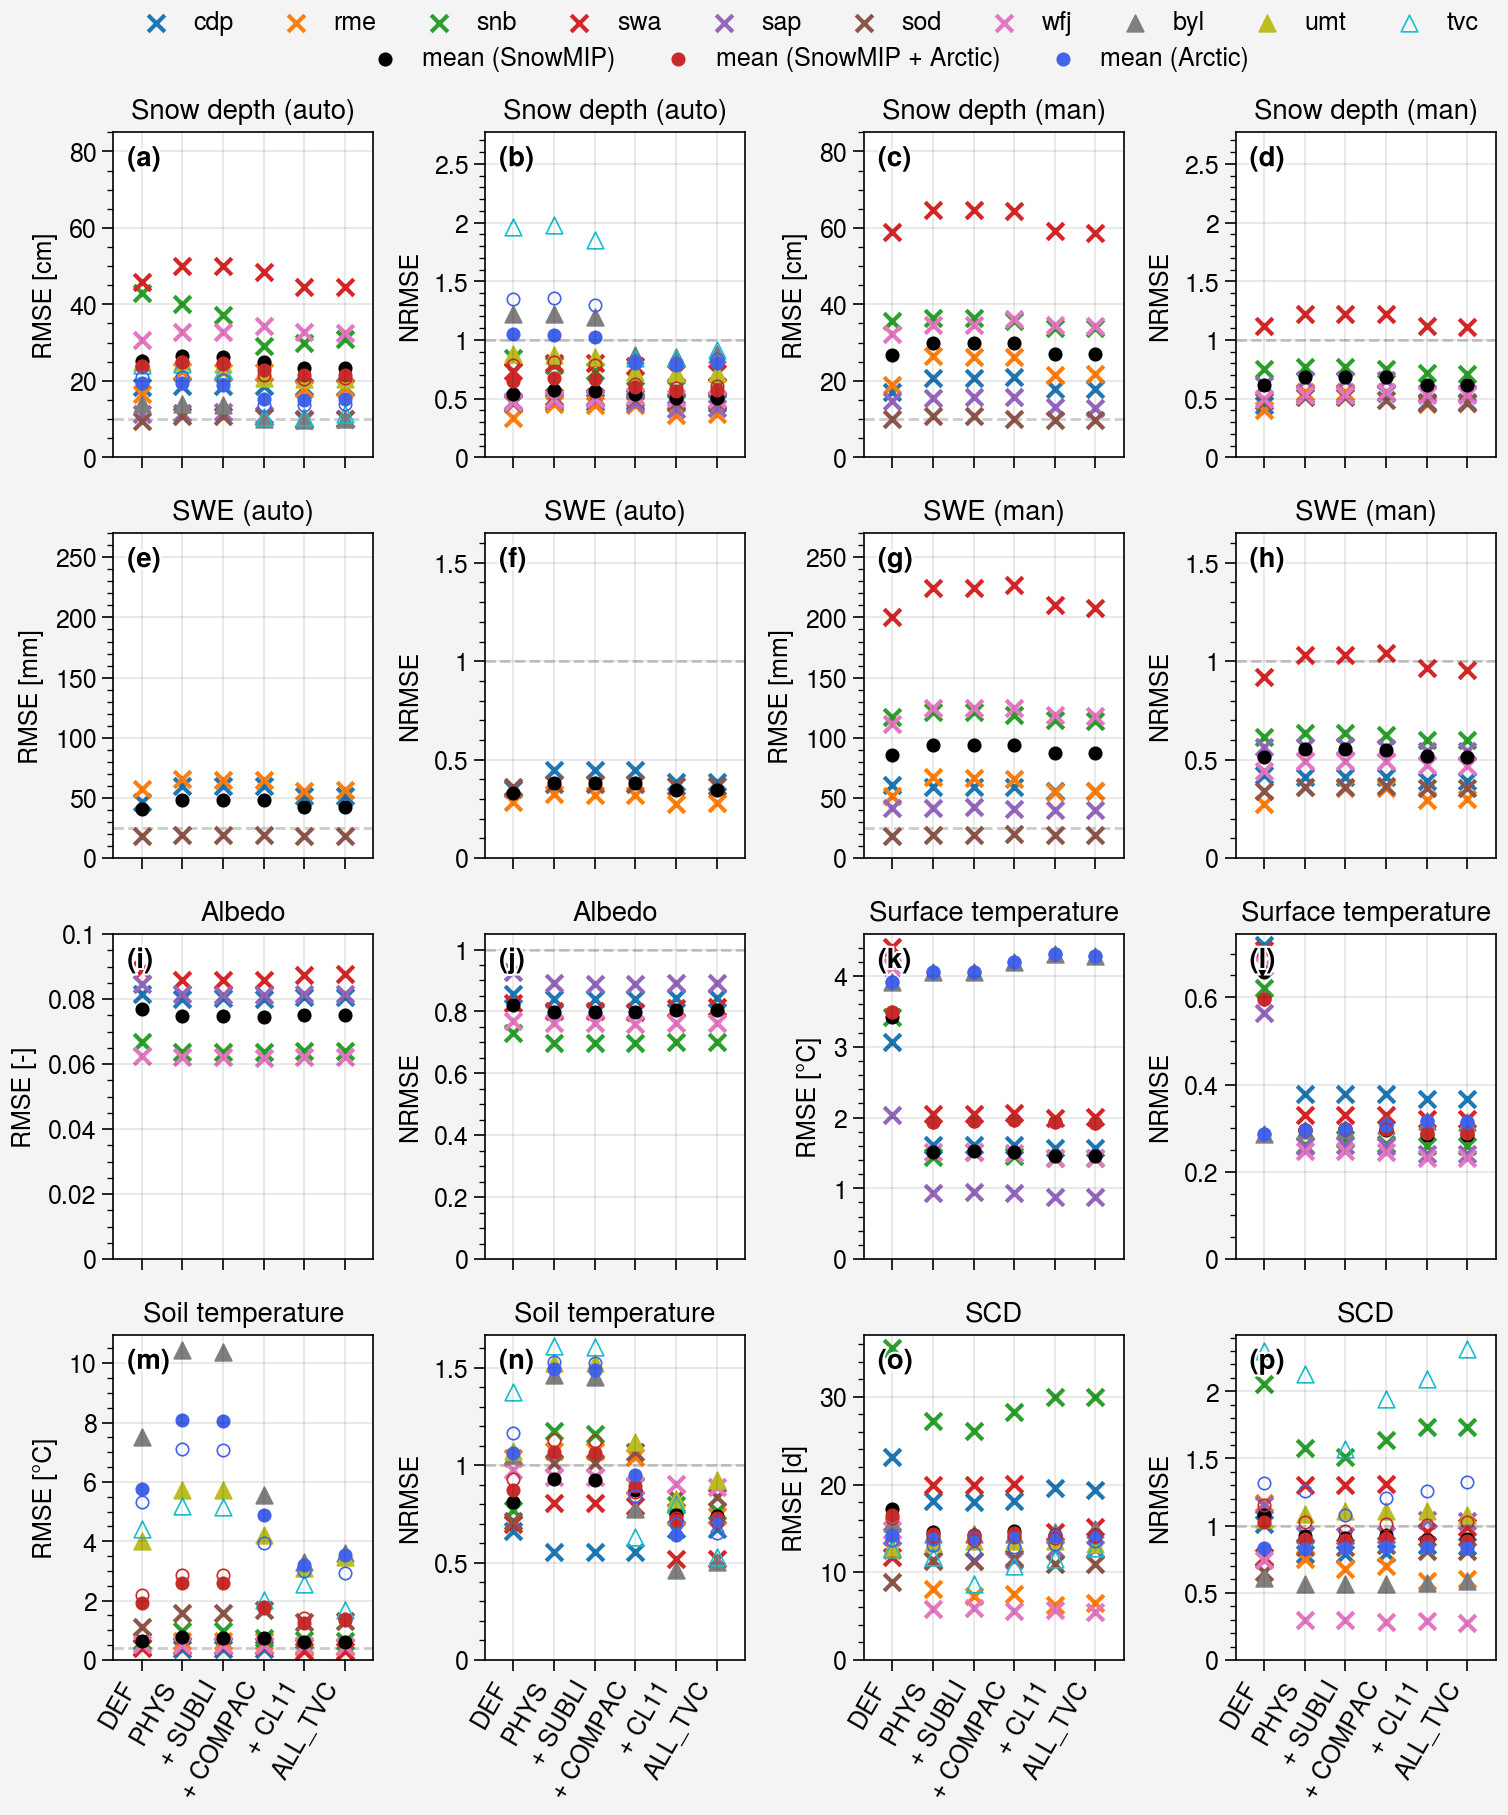

In [32]:
fig, axs = pplt.subplots(ncols=4, nrows=4, sharey=0, refaspect=0.8, refwidth=1.3)

colors = pplt.constructor.Cycle('default').by_key()['color']+pplt.constructor.Cycle('Accent').by_key()['color']
xrotation = 60
markers = ['x']*len(SnowMIP_sites) + ['^']*len(SnowArctic_sites)
marker_mean='.'; label_mean='mean (SnowMIP)'; color_mean='k'; marker_mean_size=80
marker_mean_arc='.'; label_mean_arc='mean (SnowMIP + Arctic)'; color_mean_arc='red9'; marker_mean_arc_size=80
marker_mean_arc_only='.'; label_mean_arc_only='mean (Arctic)'; color_mean_arc_only='indigo7'; marker_mean_arc_only_size=80

# Snow depth
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[0].scatter(df_metrics_list[i].loc[('snd_auto')].rmse[1:]*100, marker=markers[i], label=site.name, 
                           edgecolors=colors[i], facecolors='none')
    else:
        h = axs[0].scatter(df_metrics_list[i].loc[('snd_auto')].rmse[1:]*100, marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[0].scatter(df_gather.loc[('snd_auto')].rmse[1:].apply(np.mean)*100, 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
axs[0].format(title='Snow depth (auto)', ylabel='RMSE [cm]', xrotation=xrotation, ylim=(0, 85))


# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
h_mean_arc_noTVC = axs[0].scatter(df_gather_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean)*100, 
                                  marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, 
                                  markersize=marker_mean_arc_size)
h_mean_arc_only_noTVC = axs[0].scatter(df_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean)*100, 
                                       marker=marker_mean_arc_only, label=label_mean_arc_only, color=color_mean_arc_only, 
                                       markersize=marker_mean_arc_only_size)

h_mean_arc = axs[0].scatter(df_gather_Arctic.loc[('snd_auto')].rmse[1:].apply(np.mean)*100, marker=marker_mean_arc, 
                            label=label_mean_arc, edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
h_mean_arc_only = axs[0].scatter(df_Arctic.loc[('snd_auto')].rmse[1:].apply(np.mean)*100, marker=marker_mean_arc_only, 
                                 label=label_mean_arc_only, edgecolors=color_mean_arc_only, facecolors='none', 
                                 markersize=marker_mean_arc_only_size)

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[2].scatter(df_metrics_list[i].loc[('snd_man')].rmse[1:]*100, marker=markers[i], label=site.name, color=colors[i])
axs[2].scatter(df_gather.loc[('snd_man')].rmse[1:].apply(np.mean)*100, 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[2].scatter(df_gather_Arctic.loc[('snd_man')].rmse[1:].apply(np.nanmean)*100, 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[2].format(title='Snow depth (man)', ylabel='RMSE [cm]', xrotation=xrotation, ylim=(0, 85))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        axs[1].scatter(df_metrics_list[i].loc[('snd_auto')].nrmse[1:], 
                       marker=markers[i], label=site.name, edgecolors=colors[i], facecolors='none')
    else:
        axs[1].scatter(df_metrics_list[i].loc[('snd_auto')].nrmse[1:], 
                       marker=markers[i], label=site.name, color=colors[i])
axs[1].scatter(df_gather.loc[('snd_auto')].nrmse[1:].apply(np.mean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[1].scatter(df_gather_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean), marker=marker_mean_arc, 
               label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[1].scatter(df_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean), marker=marker_mean_arc_only, 
               label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[1].scatter(df_gather_Arctic.loc[('snd_auto')].nrmse[1:].apply(np.mean), marker=marker_mean_arc, label=label_mean_arc, 
               edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[1].scatter(df_Arctic.loc[('snd_auto')].nrmse[1:].apply(np.mean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
               edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

# axs[1].format(title='Snow depth (auto)', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 1.58))
axs[1].format(title='Snow depth (auto)', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 2.77))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[3].scatter(df_metrics_list[i].loc[('snd_man')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
axs[3].scatter(df_gather.loc[('snd_man')].nrmse[1:].apply(np.mean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[3].scatter(df_gather_Arctic.loc[('snd_man')].nrmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[3].format(title='Snow depth (man)', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 2.77))


# Snow Water Equivalent
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[4].scatter(df_metrics_list[i].loc[('snw_auto')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[4].scatter(df_gather.loc[('snw_auto')].rmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[4].scatter(df_gather_Arctic.loc[('snw_auto')].rmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[4].format(title='SWE (auto)', ylabel='RMSE [mm]', xrotation=xrotation, ylim=(0, 270))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[6].scatter(df_metrics_list[i].loc[('snw_man')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
axs[6].scatter(df_gather.loc[('snw_man')].rmse[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[6].scatter(df_gather_Arctic.loc[('snw_man')].rmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[6].format(title='SWE (man)', ylabel='RMSE [mm]', xrotation=xrotation, ylim=(0, 270))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[5].scatter(df_metrics_list[i].loc[('snw_auto')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
axs[5].scatter(df_gather.loc[('snw_auto')].nrmse[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[5].scatter(df_gather_Arctic.loc[('snw_auto')].nrmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[5].format(title='SWE (auto)', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 1.65))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[7].scatter(df_metrics_list[i].loc[('snw_man')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
axs[7].scatter(df_gather.loc[('snw_man')].nrmse[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[7].scatter(df_gather_Arctic.loc[('snw_man')].nrmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[7].format(title='SWE (man)', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 1.65))


# Albedo
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[8].scatter(df_metrics_list[i].loc[('albs')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[8].scatter(df_gather.loc[('albs')].rmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[8].scatter(df_gather_Arctic.loc[('albs')].rmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[8].format(title='Albedo', ylabel='RMSE [-]', xrotation=xrotation, ylim=(0, 0.1))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[9].scatter(df_metrics_list[i].loc[('albs')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[9].scatter(df_gather.loc[('albs')].nrmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[9].scatter(df_gather_Arctic.loc[('albs')].nrmse[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[9].format(title='Albedo', ylabel='NRMSE', xrotation=xrotation, ylim=(0, 1.05))

# Surface temperature
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[10].scatter(df_metrics_list[i].loc[('ts')].rmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[10].scatter(df_metrics_list[i].loc[('ts')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[10].scatter(df_gather.loc[('ts')].rmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[10].scatter(df_gather_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[10].scatter(df_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[10].scatter(df_gather_Arctic.loc[('ts')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[10].scatter(df_Arctic.loc[('ts')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[10].format(title='Surface temperature', ylabel='RMSE [°C]', xrotation=xrotation, ylim=(0, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[11].scatter(df_metrics_list[i].loc[('ts')].nrmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[11].scatter(df_metrics_list[i].loc[('ts')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[11].scatter(df_gather.loc[('ts')].nrmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[11].scatter(df_gather_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[11].scatter(df_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[11].scatter(df_gather_Arctic.loc[('ts')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[11].scatter(df_Arctic.loc[('ts')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[11].format(title='Surface temperature', ylabel='NRMSE', xrotation=xrotation, ylim=(0, None))

# Soil temperature
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[12].scatter(df_metrics_list[i].loc[('tsl')].rmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[12].scatter(df_metrics_list[i].loc[('tsl')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[12].scatter(df_gather.loc[('tsl')].rmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[12].scatter(df_gather_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[12].scatter(df_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[12].scatter(df_gather_Arctic.loc[('tsl')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[12].scatter(df_Arctic.loc[('tsl')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[12].format(title='Soil temperature', ylabel='RMSE [°C]', xrotation=xrotation, ylim=(0, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[13].scatter(df_metrics_list[i].loc[('tsl')].nrmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[13].scatter(df_metrics_list[i].loc[('tsl')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[13].scatter(df_gather.loc[('tsl')].nrmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[13].scatter(df_gather_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[13].scatter(df_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[13].scatter(df_gather_Arctic.loc[('tsl')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[13].scatter(df_Arctic.loc[('tsl')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[13].format(title='Soil temperature', ylabel='NRMSE', xrotation=xrotation, ylim=(0, None))

# SCD
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[14].scatter(df_metrics_list[i].loc[('SCD')].rmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[14].scatter(df_metrics_list[i].loc[('SCD')].rmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[14].scatter(df_gather.loc[('SCD')].rmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[14].scatter(df_gather_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[14].scatter(df_Arctic['rmse'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[14].scatter(df_gather_Arctic.loc[('SCD')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[14].scatter(df_Arctic.loc[('SCD')].rmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[14].format(title='SCD', ylabel='RMSE [d]', xrotation=xrotation, ylim=(0, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[15].scatter(df_metrics_list[i].loc[('SCD')].nrmse[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[15].scatter(df_metrics_list[i].loc[('SCD')].nrmse[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[15].scatter(df_gather.loc[('SCD')].nrmse[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[15].scatter(df_gather_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[15].scatter(df_Arctic['nrmse'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[15].scatter(df_gather_Arctic.loc[('SCD')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[15].scatter(df_Arctic.loc[('SCD')].nrmse[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[15].format(title='SCD', ylabel='NRMSE', xrotation=xrotation, ylim=(0, None))

x_min = -0.7
# x_max = 2.7
x_max = 5.7
for i, ax in enumerate(axs):
    # ax.format(xticklabels=['CLASS']+[exp[:-10] for exp in exps], xlim=(x_min, x_max))
    ax.format(xticklabels=label_exps, xlim=(x_min, x_max))
    if (i % 2) != 0:
        ax.hlines(1, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

# Snow Depth uncertainty
axs[0].hlines(10, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')
axs[2].hlines(10, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

# SWE uncertainty
axs[4].hlines(25, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')
axs[6].hlines(25, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

# Soil temp uncertainty
axs[12].hlines(0.4, x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

    
fig.legend(h_list+[h_mean, h_mean_arc_noTVC, h_mean_arc_only_noTVC], loc='t', ncols=len(SnowMIP_sites)+len(SnowArctic_sites), center=True, frame=False)
fig.format(abc='(a)', abcloc='ul')
# fig.save('img/paper_rmse_all_v5_correct_SH.jpg')
# fig.save('img/paper_rmse_all_v5_correct_SH.png')
# fig.save('img/paper_rmse_all_v5_correct_SH.pdf')

### Scores

#### NRMSE

In [33]:
score_array = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather.loc[(var)].nrmse[1:].apply(np.nanmean).values)
score_array = np.array(score_array).mean(axis=0)
score_array

array([0.67110749, 0.64269356, 0.63931229, 0.63117877, 0.587956  ,
       0.58794375])

In [34]:
score_array = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather_Arctic.loc[(var)].nrmse[1:].apply(np.nanmean).values)
score_array = np.array(score_array).mean(axis=0)
score_array

array([0.71775134, 0.70980455, 0.6984461 , 0.65097129, 0.61172286,
       0.61346882])

In [35]:
score_array = []
for var in ['snd_auto', 'ts', 'tsl', 'SCD']:
    score_array.append(df_Arctic.loc[(var)].nrmse[1:].apply(np.nanmean).values)
score_array = np.array(score_array).mean(axis=0)
score_array

array([1.03176609, 1.11111251, 1.05096809, 0.79364514, 0.76911918,
       0.78232535])

#### Score (no weights)

In [36]:
# No weight (I guess not good because raising the score because of lesser stations for SWE_auto
# -> raising artificially the score
score_array = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather.loc[(var)].score[1:].apply(np.nanmean).values)
score_array = np.array(score_array).mean(axis=0)
score_array

array([0.32889251, 0.35730644, 0.36068771, 0.36882123, 0.412044  ,
       0.41205625])

In [37]:
# No weight (I guess not good because raising the score because of lesser stations for SWE_auto
# -> raising artificially the score
score_array = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
score_array = np.array(score_array).mean(axis=0)
score_array

array([0.28224866, 0.29019545, 0.3015539 , 0.34902871, 0.38827714,
       0.38653118])

#### Score (weights) without TVC

In [38]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_gather.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.30877295, 0.33310731, 0.33717116, 0.34546976, 0.39077131,
       0.39077653])

In [39]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather_Arctic.loc[(var)].score[1:].apply(lambda x: x[:-1]).apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:].apply(lambda x: x[:-1])['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.28413099, 0.28953912, 0.29357239, 0.32878125, 0.37973522,
       0.37718405])

In [40]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'ts', 'tsl', 'SCD']:
    score_array.append(df_Arctic.loc[(var)].score[1:].apply(lambda x: x[:-1]).apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_Arctic.loc[(var)].score[1:].apply(lambda x: x[:-1])['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([ 0.11867776, -0.00299013,  0.00083779,  0.21672983,  0.30563574,
        0.28592022])

#### Score (weights) with TVC

In [41]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_gather.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.30877295, 0.33310731, 0.33717116, 0.34546976, 0.39077131,
       0.39077653])

In [42]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.22287302, 0.2266071 , 0.24262065, 0.30399944, 0.34679693,
       0.34394922])

In [43]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'ts', 'tsl', 'SCD']:
    score_array.append(df_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([-0.18085667, -0.2739439 , -0.20176679,  0.10908894,  0.14011737,
        0.12386089])

### SCD excluded

In [44]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl']:
    score_array.append(df_gather_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.30261495, 0.28035346, 0.28528475, 0.37146602, 0.42146618,
       0.42298845])

In [45]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'ts', 'tsl']:
    score_array.append(df_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([-0.120769  , -0.28002363, -0.25362486,  0.24463631,  0.31105961,
        0.31672591])

In [46]:
df_gather.loc[('snd_auto')].mb.apply(lambda x: [round(v, 3) for v in x])

Obs                                                           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
DEF                                             [0.057, -0.024, 0.314, -0.383, -0.008, -0.061,...
BUG_CORRECT_TSNBT_OP1_EZERO                     [-0.022, -0.119, 0.268, -0.426, -0.031, -0.069...
PHYS_ALL_SUBLI_v2                               [-0.023, -0.119, 0.231, -0.426, -0.033, -0.069...
PHYS_ALL_SUBLI_v2_COMPAC_v1                     [-0.024, -0.122, 0.128, -0.404, -0.044, -0.05,...
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             [0.03, -0.058, 0.145, -0.369, -0.007, -0.047, ...
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    [0.032, -0.055, 0.164, -0.369, -0.003, -0.047,...
Name: mb, dtype: object

In [47]:
df_Arctic.loc[('snd_auto')].mb.apply(lambda x: [round(v, 3) for v in x])

Obs                                                    [0.0, 0.0, 0.0]
DEF                                               [0.092, 0.079, 0.19]
BUG_CORRECT_TSNBT_OP1_EZERO                        [0.086, 0.08, 0.19]
PHYS_ALL_SUBLI_v2                                [0.082, 0.066, 0.174]
PHYS_ALL_SUBLI_v2_COMPAC_v1                     [0.004, -0.079, 0.045]
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             [0.004, -0.072, 0.046]
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne     [0.019, -0.052, 0.06]
Name: mb, dtype: object

In [48]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'ts', 'tsl', 'SCD']:
    score_array.append(df_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([-0.18085667, -0.2739439 , -0.20176679,  0.10908894,  0.14011737,
        0.12386089])

In [49]:
# Best score?
score_array = []
weights = []
for var in ['snd_auto', 'ts', 'tsl']:
    score_array.append(df_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites (give twice more weight to sn from auto/man)
    # Make sense because other variable have smaller std and so higher NRMSE
    # (which might give them too much importance)
    # weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
    weight = np.nansum(df_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
    #     weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([-0.120769  , -0.28002363, -0.25362486,  0.24463631,  0.31105961,
        0.31672591])

In [50]:
# # Best score?
# score_array = []
# weights = []
# for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
#     score_array.append(df_gather_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
#     # Weight per obs sites (give twice more weight to sn from auto/man)
#     # Make sense because other variable have smaller std and so higher NRMSE
#     # (which might give them too much importance)
#     weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['Ref_30min_ext']*0+1)
#     # if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
#     #     weight = weight*0.5
#     weights.append(weight)
# score_array = np.average(np.array(score_array), axis=0, weights=weights)
# score_array

In [51]:
# Alternative score
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites and 0.5 for sn auto/man
    weight = np.nansum(df_gather.loc[(var)].score[1:]['DEF']*0+1)
    if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
        weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.25288688, 0.30211956, 0.30687368, 0.31466959, 0.36019319,
       0.36023027])

In [52]:
# Alternative score
score_array = []
weights = []
for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
    score_array.append(df_gather_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites and 0.5 for sn auto/man
    weight = np.nansum(df_gather_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
        weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([0.17406528, 0.19240357, 0.21088115, 0.27198189, 0.3153452 ,
       0.31276213])

In [53]:
# Alternative score
score_array = []
weights = []
for var in ['snd_auto', 'ts', 'tsl', 'SCD']:
    score_array.append(df_Arctic.loc[(var)].score[1:].apply(np.nanmean).values)
    # Weight per obs sites and 0.5 for sn auto/man
    weight = np.nansum(df_Arctic.loc[(var)].score[1:]['DEF']*0+1)
    if var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man']:
        weight = weight*0.5
    weights.append(weight)
score_array = np.average(np.array(score_array), axis=0, weights=weights)
score_array

array([-0.15049423, -0.25936814, -0.1843822 ,  0.096209  ,  0.13067703,
        0.11730511])

### Mean bias

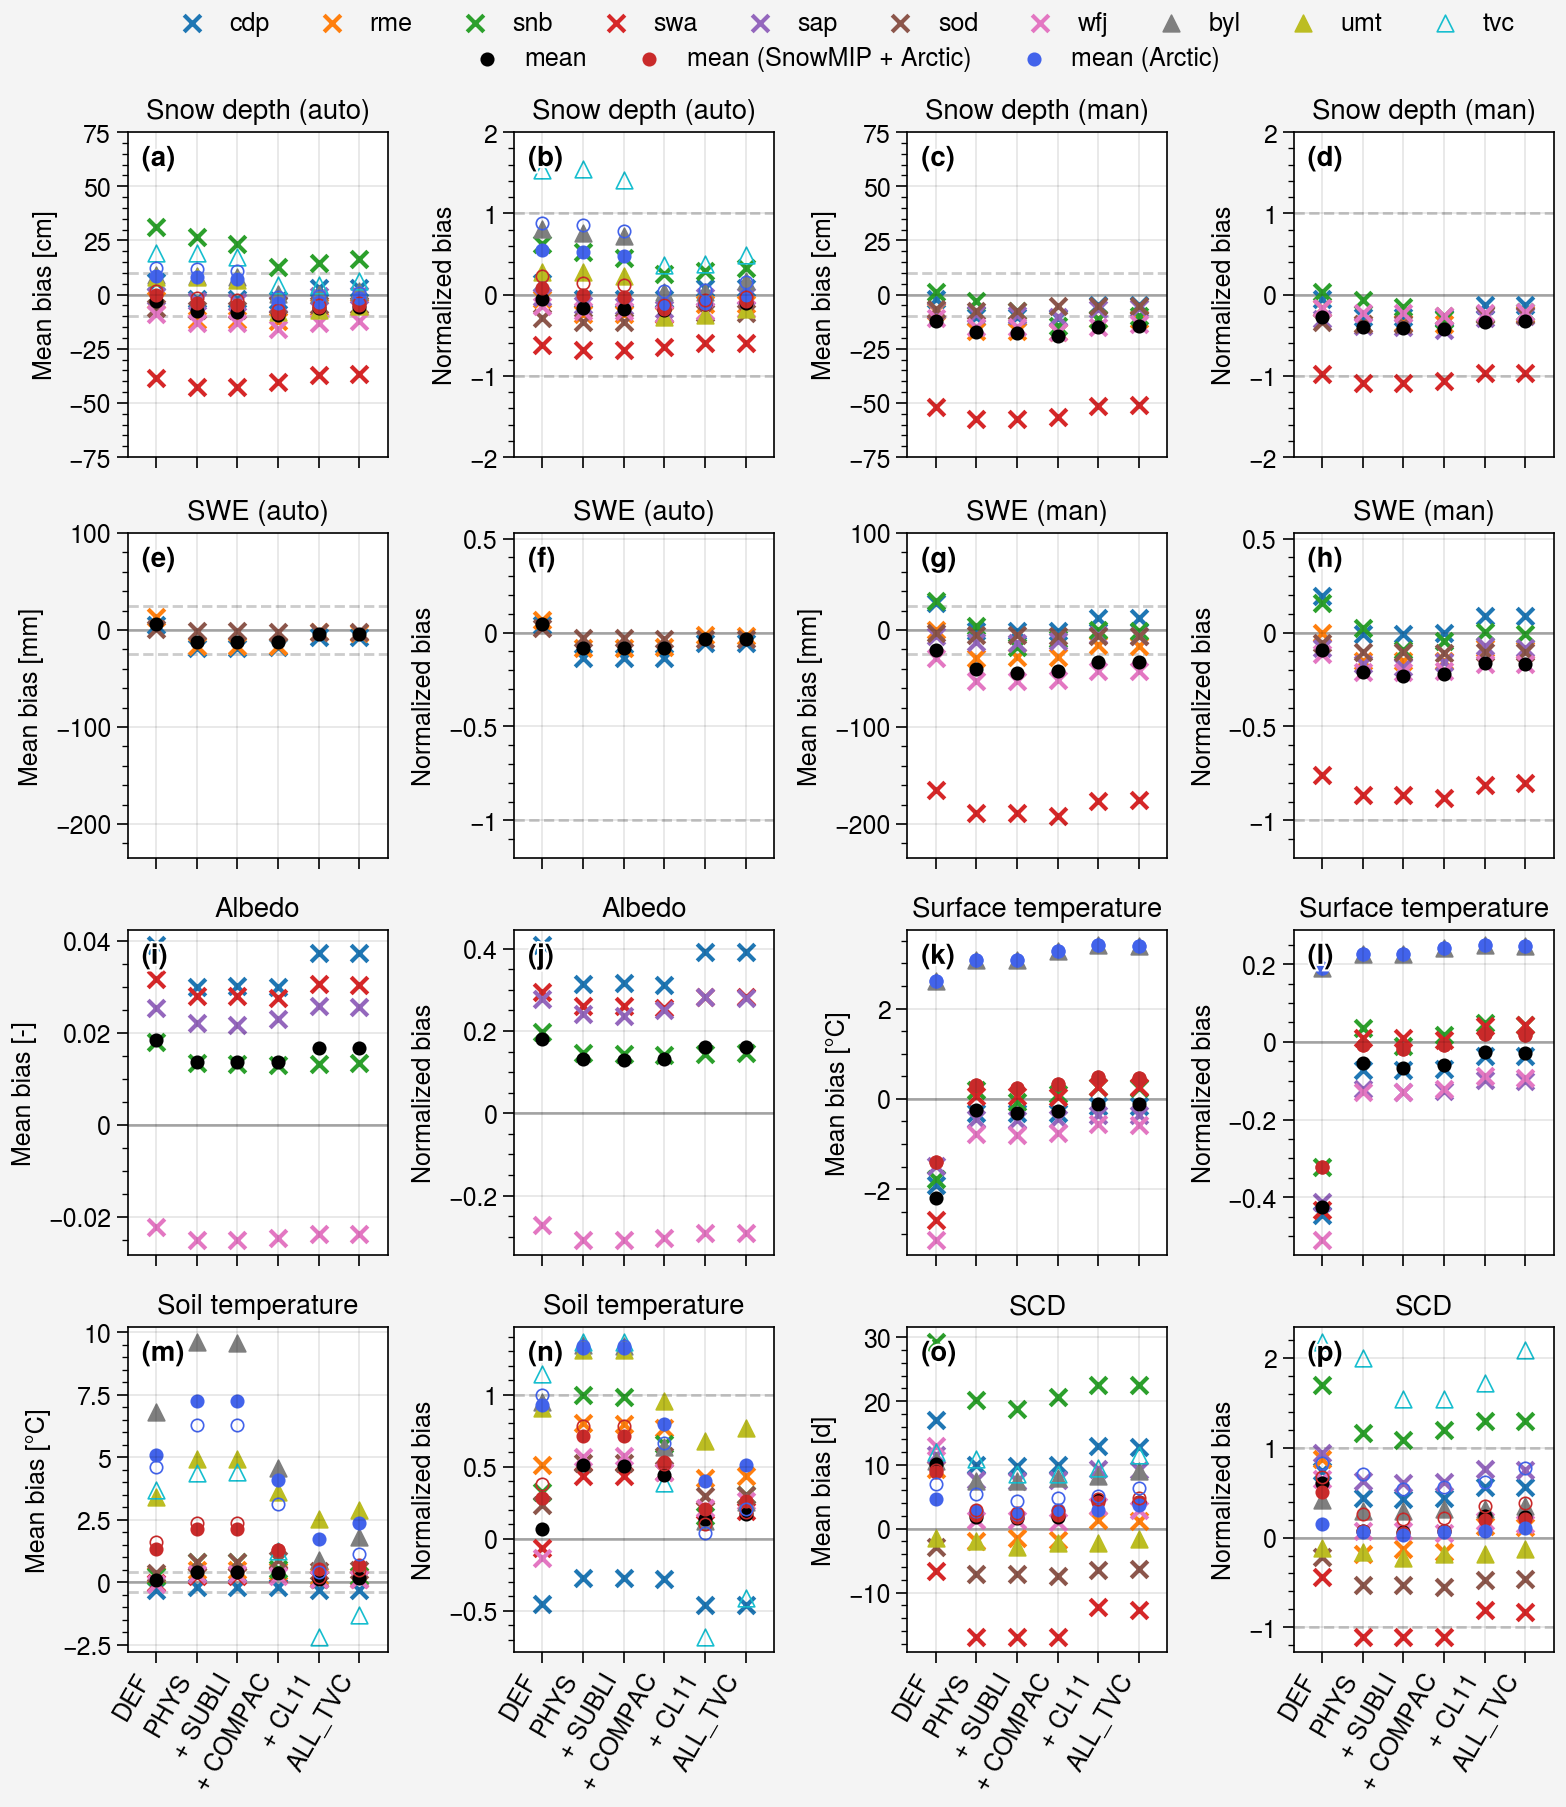

In [54]:
fig, axs = pplt.subplots(ncols=4, nrows=4, sharey=0, refaspect=0.8, refwidth=1.3)

colors = pplt.constructor.Cycle('default').by_key()['color']+pplt.constructor.Cycle('Accent').by_key()['color']
xrotation=60
markers = ['x']*len(SnowMIP_sites) + ['^']*len(SnowArctic_sites)
marker_mean='.'; label_mean='mean'; color_mean='k'; marker_mean_size=80
marker_mean_arc='.'; label_mean_arc='mean (SnowMIP + Arctic)'; color_mean_arc='red9'; marker_mean_arc_size=80
marker_mean_arc_only='.'; label_mean_arc_only='mean (Arctic)'; color_mean_arc_only='indigo7'; marker_mean_arc_only_size=80


# Snow depth
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[0].scatter(df_metrics_list[i].loc[('snd_auto')].mb[1:]*100, marker=markers[i], label=site.name, 
                           edgecolors=colors[i], facecolors='none')
    else:
        h = axs[0].scatter(df_metrics_list[i].loc[('snd_auto')].mb[1:]*100, marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[0].scatter(df_gather.loc[('snd_auto')].mb[1:].apply(np.mean)*100, 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
h_mean_arc_noTVC = axs[0].scatter(df_gather_Arctic['mb'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean)*100, 
                                  marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
h_mean_arc_only_noTVC = axs[0].scatter(df_Arctic['mb'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean)*100, 
                                       marker=marker_mean_arc_only, label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

h_mean_arc = axs[0].scatter(df_gather_Arctic.loc[('snd_auto')].mb[1:].apply(np.mean)*100, marker=marker_mean_arc, 
                            label=label_mean_arc, edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
h_mean_arc_only = axs[0].scatter(df_Arctic.loc[('snd_auto')].mb[1:].apply(np.mean)*100, marker=marker_mean_arc_only, 
                                 label=label_mean_arc_only, edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[0].format(title='Snow depth (auto)', ylabel='Mean bias [cm]', xrotation=xrotation, ylim=(-75, 75))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[2].scatter(df_metrics_list[i].loc[('snd_man')].mb[1:]*100, marker=markers[i], label=site.name, color=colors[i])
axs[2].scatter(df_gather.loc[('snd_man')].mb[1:].apply(np.mean)*100, 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[2].scatter(df_gather_Arctic.loc[('snd_man')].mb[1:].apply(np.nanmean)*100, 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[2].format(title='Snow depth (man)', ylabel='Mean bias [cm]', xrotation=xrotation, ylim=(-75, 75))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        axs[1].scatter(df_metrics_list[i].loc[('snd_auto')].nmb[1:], 
                       marker=markers[i], label=site.name, edgecolors=colors[i], facecolors='none')
    else:
        axs[1].scatter(df_metrics_list[i].loc[('snd_auto')].nmb[1:], 
                       marker=markers[i], label=site.name, color=colors[i])
axs[1].scatter(df_gather.loc[('snd_auto')].nmb[1:].apply(np.mean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[1].scatter(df_gather_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean), marker=marker_mean_arc, 
               label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[1].scatter(df_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('snd_auto')][1:].apply(np.mean), marker=marker_mean_arc_only, 
               label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)
                                 
axs[1].scatter(df_gather_Arctic.loc[('snd_auto')].nmb[1:].apply(np.mean), marker=marker_mean_arc, label=label_mean_arc, 
               edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[1].scatter(df_Arctic.loc[('snd_auto')].nmb[1:].apply(np.mean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
               edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[1].format(title='Snow depth (auto)', ylabel='Normalized bias', xrotation=xrotation, ylim=(-2, 2))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[3].scatter(df_metrics_list[i].loc[('snd_man')].nmb[1:], 
                   marker=markers[i], label=site.name, color=colors[i])
axs[3].scatter(df_gather.loc[('snd_man')].nmb[1:].apply(np.mean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[3].scatter(df_gather_Arctic.loc[('snd_man')].nmb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[3].format(title='Snow depth (man)', ylabel='Normalized bias', xrotation=xrotation, ylim=(-2, 2))


# Snow Water Equivalent
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[4].scatter(df_metrics_list[i].loc[('snw_auto')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[4].scatter(df_gather.loc[('snw_auto')].mb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[4].scatter(df_gather_Arctic.loc[('snw_auto')].mb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[4].format(title='SWE (auto)', ylabel='Mean bias [mm]', xrotation=xrotation, ylim=(-235, 100))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[6].scatter(df_metrics_list[i].loc[('snw_man')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
axs[6].scatter(df_gather.loc[('snw_man')].mb[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[6].scatter(df_gather_Arctic.loc[('snw_man')].mb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[6].format(title='SWE (man)', ylabel='Mean bias [mm]', xrotation=xrotation, ylim=(-235, 100))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[5].scatter(df_metrics_list[i].loc[('snw_auto')].nmb[1:], 
                   marker=markers[i], label=site.name, color=colors[i])
axs[5].scatter(df_gather.loc[('snw_auto')].nmb[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[5].scatter(df_gather_Arctic.loc[('snw_auto')].nmb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[5].format(title='SWE (auto)', ylabel='Normalized bias', xrotation=xrotation, ylim=(-1.2, 0.53))

for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    axs[7].scatter(df_metrics_list[i].loc[('snw_man')].nmb[1:], 
                   marker=markers[i], label=site.name, color=colors[i])
axs[7].scatter(df_gather.loc[('snw_man')].nmb[1:].apply(np.nanmean), 
               marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[7].scatter(df_gather_Arctic.loc[('snw_man')].nmb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[7].format(title='SWE (man)', ylabel='Normalized bias', xrotation=xrotation, ylim=(-1.2, 0.53))


# Albedo
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[8].scatter(df_metrics_list[i].loc[('albs')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[8].scatter(df_gather.loc[('albs')].mb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[8].scatter(df_gather_Arctic.loc[('albs')].mb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[8].format(title='Albedo', ylabel='Mean bias [-]', xrotation=xrotation, ylim=(None, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    h = axs[9].scatter(df_metrics_list[i].loc[('albs')].nmb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[9].scatter(df_gather.loc[('albs')].nmb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)
# axs[9].scatter(df_gather_Arctic.loc[('albs')].nmb[1:].apply(np.nanmean), 
#                 marker=marker_mean_arc, label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[9].format(title='Albedo', ylabel='Normalized bias', xrotation=xrotation, ylim=(None, None))

# Surface temperature
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[10].scatter(df_metrics_list[i].loc[('ts')].mb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[10].scatter(df_metrics_list[i].loc[('ts')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[10].scatter(df_gather.loc[('ts')].mb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[10].scatter(df_gather_Arctic['mb'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[10].scatter(df_Arctic['mb'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[10].scatter(df_gather_Arctic.loc[('ts')].mb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[10].scatter(df_Arctic.loc[('ts')].mb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[10].format(title='Surface temperature', ylabel='Mean bias [°C]', xrotation=xrotation, ylim=(None, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[11].scatter(df_metrics_list[i].loc[('ts')].nmb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[11].scatter(df_metrics_list[i].loc[('ts')].nmb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[11].scatter(df_gather.loc[('ts')].nmb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[11].scatter(df_gather_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[11].scatter(df_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('ts')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[11].scatter(df_gather_Arctic.loc[('ts')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[11].scatter(df_Arctic.loc[('ts')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[11].format(title='Surface temperature', ylabel='Normalized bias', xrotation=xrotation, ylim=(None, None))

# Soil temperature
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[12].scatter(df_metrics_list[i].loc[('tsl')].mb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[12].scatter(df_metrics_list[i].loc[('tsl')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[12].scatter(df_gather.loc[('tsl')].mb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[12].scatter(df_gather_Arctic['mb'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[12].scatter(df_Arctic['mb'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[12].scatter(df_gather_Arctic.loc[('tsl')].mb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[12].scatter(df_Arctic.loc[('tsl')].mb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[12].format(title='Soil temperature', ylabel='Mean bias [°C]', xrotation=xrotation, ylim=(None, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[13].scatter(df_metrics_list[i].loc[('tsl')].nmb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[13].scatter(df_metrics_list[i].loc[('tsl')].nmb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[13].scatter(df_gather.loc[('tsl')].nmb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[13].scatter(df_gather_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[13].scatter(df_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('tsl')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[13].scatter(df_gather_Arctic.loc[('tsl')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[13].scatter(df_Arctic.loc[('tsl')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[13].format(title='Soil temperature', ylabel='Normalized bias', xrotation=xrotation, ylim=(None, None))

# SCD
h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[14].scatter(df_metrics_list[i].loc[('SCD')].mb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[14].scatter(df_metrics_list[i].loc[('SCD')].mb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[14].scatter(df_gather.loc[('SCD')].mb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[14].scatter(df_gather_Arctic['mb'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[14].scatter(df_Arctic['mb'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[14].scatter(df_gather_Arctic.loc[('SCD')].mb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[14].scatter(df_Arctic.loc[('SCD')].mb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[14].format(title='SCD', ylabel='Mean bias [d]', xrotation=xrotation, ylim=(None, None))

h_list = []
for i, site in enumerate(SnowMIP_sites+SnowArctic_sites):
    if site.name == 'tvc':
        h = axs[15].scatter(df_metrics_list[i].loc[('SCD')].nmb[1:], marker=markers[i], label=site.name, 
                            edgecolors=colors[i], facecolors='none')
    else:
        h = axs[15].scatter(df_metrics_list[i].loc[('SCD')].nmb[1:], marker=markers[i], label=site.name, color=colors[i])
    h_list.append(h)
h_mean = axs[15].scatter(df_gather.loc[('SCD')].nmb[1:].apply(np.nanmean), 
                        marker=marker_mean, label=label_mean, color=color_mean, markersize=marker_mean_size)

# Without TVC
# (remove the last value with .apply(lambda x: x[:-1])
axs[15].scatter(df_gather_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc, 
                label=label_mean_arc, color=color_mean_arc, markersize=marker_mean_arc_size)
axs[15].scatter(df_Arctic['nmb'].apply(lambda x: x[:-1]).loc[('SCD')][1:].apply(np.nanmean), marker=marker_mean_arc_only, 
                label=label_mean_arc_only, color=color_mean_arc_only, markersize=marker_mean_arc_only_size)

axs[15].scatter(df_gather_Arctic.loc[('SCD')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc, label=label_mean_arc, 
                edgecolors=color_mean_arc, facecolors='none', markersize=marker_mean_arc_size)
axs[15].scatter(df_Arctic.loc[('SCD')].nmb[1:].apply(np.nanmean), marker=marker_mean_arc_only, label=label_mean_arc_only, 
                edgecolors=color_mean_arc_only, facecolors='none', markersize=marker_mean_arc_only_size)

axs[15].format(title='SCD', ylabel='Normalized bias', xrotation=xrotation, ylim=(None, None))

x_min = -0.7
x_max = 5.7
for ax in axs:
    # ax.format(xticklabels=['CLASS']+[exp[:-10] for exp in exps], xlim=(x_min, x_max))
    ax.format(xticklabels=label_exps, xlim=(x_min, x_max))
    ax.hlines(0, x_min, x_max, color='k', lw=1, alpha=0.3, zorder=0, ls='-')

# Obs uncertainties (base on Lejeune et al. (2019) at cdp)
axs[0].hlines([-10, 10], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')
axs[2].hlines([-10, 10], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

axs[4].hlines([-25, 25], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')
axs[6].hlines([-25, 25], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

axs[12].hlines([-0.4, 0.4], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

for i, ax in enumerate(axs):
    if (i % 2) != 0:
        ax.hlines([-1, 1], x_min, x_max, color='k', lw=1, alpha=0.2, zorder=0, ls='--')

    
fig.legend(h_list+[h_mean, h_mean_arc_noTVC, h_mean_arc_only_noTVC], loc='t', ncols=len(SnowMIP_sites)+len(SnowArctic_sites), center=True, frame=False)
fig.format(abc='(a)', abcloc='ul')
# fig.save('img/paper_mb_all_v5_correct_SH.jpg')
# fig.save('img/paper_mb_all_v5_correct_SH.png')
# fig.save('img/paper_mb_all_v5_correct_SH.pdf')

In [55]:
# for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
for var in ['ts']:
    print('###############')
    print('### SnowMIP ###')
    print('###############')
    print('MB')
    print('df_gather.loc[('+var+')].mb[1:]')
    print(df_gather.loc[(var)].mb[1:].apply(np.nanmean))
    
    print('\ndf_gather.loc[('+var+')].nmb[1:]')
    print(df_gather.loc[(var)].nmb[1:].apply(np.nanmean))

    print('\nRMSE')
    print('df_gather.loc[('+var+')]rmse[1:]')
    print(df_gather.loc[(var)].rmse[1:].apply(np.nanmean))
    
    print('\ndf_gather.loc[('+var+')].nrmse[1:]')
    print(df_gather.loc[(var)].nrmse[1:].apply(np.nanmean))

    print('\nr')
    print('df_gather.loc[('+var+')]r[1:]')
    print(df_gather.loc[(var)].r[1:].apply(np.nanmean))
    
    
    print('\n########################')
    print('### SnowMIP + Arctic ###')
    print('########################')
    print('MB')
    print('df_gather_Arctic.loc[('+var+')].mb[1:]')
    print(df_gather_Arctic.loc[(var)].mb[1:].apply(lambda x: x[:-1]).apply(np.nanmean))
    
    print('\ndf_gather_Arctic.loc[('+var+')].nmb[1:]')
    print(df_gather_Arctic.loc[(var)].nmb[1:].apply(lambda x: x[:-1]).apply(np.nanmean))

    print('\nRMSE')
    print('df_gather_Arctic.loc[('+var+')]rmse[1:]')
    print(df_gather_Arctic.loc[(var)].rmse[1:].apply(lambda x: x[:-1]).apply(np.nanmean))
    
    print('\ndf_gather_Arctic.loc[('+var+')].nrmse[1:]')
    print(df_gather_Arctic.loc[(var)].nrmse[1:].apply(lambda x: x[:-1]).apply(np.nanmean))

    print('\nr')
    print('df_gather_Arctic.loc[('+var+')]r[1:]')
    print(df_gather_Arctic.loc[(var)].r[1:].apply(lambda x: x[:-1]).apply(np.nanmean))


    print('\n##############')
    print('### Arctic ###')
    print('##############')
    print('MB')
    print('df_Arctic.loc[('+var+')].mb[1:]')
    print(df_Arctic.loc[(var)].mb[1:].apply(lambda x: x[:-1]).apply(np.nanmean))
    
    print('\ndf_Arctic.loc[('+var+')].nmb[1:]')
    print(df_Arctic.loc[(var)].nmb[1:].apply(lambda x: x[:-1]).apply(np.nanmean))

    print('\nRMSE')
    print('df_Arctic.loc[('+var+')]rmse[1:]')
    print(df_Arctic.loc[(var)].rmse[1:].apply(lambda x: x[:-1]).apply(np.nanmean))
    
    print('\ndf_Arctic.loc[('+var+')].nrmse[1:]')
    print(df_Arctic.loc[(var)].nrmse[1:].apply(lambda x: x[:-1]).apply(np.nanmean))

    print('\nr')
    print('df_Arctic.loc[('+var+')].r[1:]')
    print(df_Arctic.loc[(var)].r[1:].apply(lambda x: x[:-1]).apply(np.nanmean))


###############
### SnowMIP ###
###############
MB
df_gather.loc[(ts)].mb[1:]
DEF                                            -2.197620
BUG_CORRECT_TSNBT_OP1_EZERO                    -0.254050
PHYS_ALL_SUBLI_v2                              -0.313592
PHYS_ALL_SUBLI_v2_COMPAC_v1                    -0.274140
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            -0.104670
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   -0.120434
Name: mb, dtype: float64

df_gather.loc[(ts)].nmb[1:]
DEF                                            -0.424718
BUG_CORRECT_TSNBT_OP1_EZERO                    -0.055044
PHYS_ALL_SUBLI_v2                              -0.066468
PHYS_ALL_SUBLI_v2_COMPAC_v1                    -0.058980
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            -0.026479
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   -0.029518
Name: nmb, dtype: float64

RMSE
df_gather.loc[(ts)]rmse[1:]
DEF                                             3.413744
BUG_CORRECT_TSNBT_OP1_EZERO                     1.510778
PHYS_ALL_S

In [56]:
# for var in ['snd_auto', 'snd_man', 'snw_auto', 'snw_man', 'albs', 'ts', 'tsl', 'SCD']:
for var in ['tsl']:
    print('###############')
    print('### SnowMIP ###')
    print('###############')
    print('MB')
    print('df_gather.loc[('+var+')].mb[1:]')
    print(df_gather.loc[(var)].mb[1:].apply(np.nanmean))
    
    print('\ndf_gather.loc[('+var+')].nmb[1:]')
    print(df_gather.loc[(var)].nmb[1:].apply(np.nanmean))

    print('\nRMSE')
    print('df_gather.loc[('+var+')]rmse[1:]')
    print(df_gather.loc[(var)].rmse[1:].apply(np.nanmean))
    
    print('\ndf_gather.loc[('+var+')].nrmse[1:]')
    print(df_gather.loc[(var)].nrmse[1:].apply(np.nanmean))
    
    print('\nr')
    print('df_gather.loc[('+var+')].r[1:]')
    print(df_gather.loc[(var)].r[1:].apply(np.nanmean))
    

    print('\n########################')
    print('### SnowMIP + Arctic ###')
    print('########################')
    print('MB')
    print('df_gather_Arctic.loc[('+var+')].mb[1:]')
    print(df_gather_Arctic.loc[(var)].mb[1:].apply(np.nanmean))
    
    print('\ndf_gather_Arctic.loc[('+var+')].nmb[1:]')
    print(df_gather_Arctic.loc[(var)].nmb[1:].apply(np.nanmean))

    print('\nRMSE')
    print('df_gather_Arctic.loc[('+var+')]rmse[1:]')
    print(df_gather_Arctic.loc[(var)].rmse[1:].apply(np.nanmean))
    
    print('\ndf_gather_Arctic.loc[('+var+')].nrmse[1:]')
    print(df_gather_Arctic.loc[(var)].nrmse[1:].apply(np.nanmean))

    print('\nr')
    print('df_gather_Arctic.loc[('+var+')].r[1:]')
    print(df_gather_Arctic.loc[(var)].r[1:].apply(np.nanmean))


    print('\n##############')
    print('### Arctic ###')
    print('##############')
    print('MB')
    print('df_Arctic.loc[('+var+')].mb[1:]')
    print(df_Arctic.loc[(var)].mb[1:].apply(np.nanmean))
    
    print('\ndf_Arctic.loc[('+var+')].nmb[1:]')
    print(df_Arctic.loc[(var)].nmb[1:].apply(np.nanmean))

    print('\nRMSE')
    print('df_Arctic.loc[('+var+')]rmse[1:]')
    print(df_Arctic.loc[(var)].rmse[1:].apply(np.nanmean))
    
    print('\ndf_Arctic.loc[('+var+')].nrmse[1:]')
    print(df_Arctic.loc[(var)].nrmse[1:].apply(np.nanmean))

    print('\nr')
    print('df_Arctic.loc[('+var+')].r[1:]')
    print(df_Arctic.loc[(var)].r[1:].apply(np.nanmean))


###############
### SnowMIP ###
###############
MB
df_gather.loc[(tsl)].mb[1:]
DEF                                             0.090144
BUG_CORRECT_TSNBT_OP1_EZERO                     0.420265
PHYS_ALL_SUBLI_v2                               0.418543
PHYS_ALL_SUBLI_v2_COMPAC_v1                     0.376807
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             0.131504
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    0.159310
Name: mb, dtype: float64

df_gather.loc[(tsl)].nmb[1:]
DEF                                             0.070326
BUG_CORRECT_TSNBT_OP1_EZERO                     0.508662
PHYS_ALL_SUBLI_v2                               0.506554
PHYS_ALL_SUBLI_v2_COMPAC_v1                     0.443058
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             0.138268
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    0.174646
Name: nmb, dtype: float64

RMSE
df_gather.loc[(tsl)]rmse[1:]
DEF                                             0.626013
BUG_CORRECT_TSNBT_OP1_EZERO                     0.757699
PHYS_AL

In [57]:
df_gather.loc[(var)].mb[1:].apply(np.nanmean)

DEF                                             0.090144
BUG_CORRECT_TSNBT_OP1_EZERO                     0.420265
PHYS_ALL_SUBLI_v2                               0.418543
PHYS_ALL_SUBLI_v2_COMPAC_v1                     0.376807
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             0.131504
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    0.159310
Name: mb, dtype: float64

In [58]:
df_Arctic.loc[(var)].mb[1:]

DEF                                             [6.8111430294249145, 3.393651583657299, 3.6806...
BUG_CORRECT_TSNBT_OP1_EZERO                     [9.615359575591642, 4.9108098152355835, 4.3829...
PHYS_ALL_SUBLI_v2                               [9.550145563976132, 4.913086893896547, 4.39180...
PHYS_ALL_SUBLI_v2_COMPAC_v1                     [4.562513144507628, 3.598888479731778, 1.25344...
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             [0.886452413064792, 2.5448561981326066, -2.192...
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    [1.8145911779165909, 2.894329692492837, -1.313...
Name: mb, dtype: object

In [59]:
df_Arctic.loc[(var)].mb[1:]

DEF                                             [6.8111430294249145, 3.393651583657299, 3.6806...
BUG_CORRECT_TSNBT_OP1_EZERO                     [9.615359575591642, 4.9108098152355835, 4.3829...
PHYS_ALL_SUBLI_v2                               [9.550145563976132, 4.913086893896547, 4.39180...
PHYS_ALL_SUBLI_v2_COMPAC_v1                     [4.562513144507628, 3.598888479731778, 1.25344...
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             [0.886452413064792, 2.5448561981326066, -2.192...
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    [1.8145911779165909, 2.894329692492837, -1.313...
Name: mb, dtype: object

In [60]:
df_Arctic['mb'].apply(lambda x: x[:-1]).loc[(var)][1:]

DEF                                             [6.8111430294249145, 3.393651583657299]
BUG_CORRECT_TSNBT_OP1_EZERO                     [9.615359575591642, 4.9108098152355835]
PHYS_ALL_SUBLI_v2                                [9.550145563976132, 4.913086893896547]
PHYS_ALL_SUBLI_v2_COMPAC_v1                      [4.562513144507628, 3.598888479731778]
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             [0.886452413064792, 2.5448561981326066]
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    [1.8145911779165909, 2.894329692492837]
Name: mb, dtype: object

## Correlations and all metric tables

In [61]:
df_gather_Arctic.loc[("snd_auto")].r

Obs                                             [0.9999999536321564, 0.9999999776013654, 1.000...
DEF                                             [0.8975601751194201, 0.9448250396238262, 0.838...
BUG_CORRECT_TSNBT_OP1_EZERO                     [0.8829147932835815, 0.9224241594819746, 0.838...
PHYS_ALL_SUBLI_v2                               [0.8827995789341073, 0.9238176333806252, 0.840...
PHYS_ALL_SUBLI_v2_COMPAC_v1                     [0.8801338876104101, 0.9265112333686779, 0.873...
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             [0.8906875564724844, 0.9429864182491993, 0.878...
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    [0.8901543037982313, 0.9402334479096365, 0.878...
Name: r, dtype: object

In [62]:
# Readable correlation tables (r): columns = short site names, rows = experiments
site_short_names = [site.name for site in (SnowMIP_sites + SnowArctic_sites)]


def _to_site_r_array(value, n_sites):
    """Convert stored r value to a fixed-length array (n_sites), padding with NaN if needed."""
    # Some entries are arrays, others can be scalar NaN (for unavailable variables/sites)
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(value, dtype=float).ravel()
    elif pd.isna(value):
        arr = np.array([], dtype=float)
    else:
        # Fallback for unexpected scalar values
        arr = np.array([value], dtype=float)

    out = np.full(n_sites, np.nan, dtype=float)
    out[: min(n_sites, arr.size)] = arr[: min(n_sites, arr.size)]
    return out


vars_all = df_gather_Arctic.index.get_level_values(0).unique()

for var in vars_all:
    # Keep same experiment rows as existing DataFrame for this variable
    sub = df_gather_Arctic.loc[(var)]

    r_table = pd.DataFrame(
        [_to_site_r_array(v, len(site_short_names)) for v in sub["r"].values],
        index=sub.index,
        columns=site_short_names,
    )

    print(f"\n### {var} ###")
    display(r_table.round(3))


### snd_auto ###


,cdp,rme,snb,swa,sap,sod,wfj,byl,umt,tvc
Obs,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
DEF,0.898,0.945,0.839,0.914,0.879,0.930,0.900,0.535,0.732,0.727
BUG_CORRECT_TSNBT_OP1_EZERO,0.883,0.922,0.839,0.900,0.880,0.913,0.897,0.495,0.746,0.720
PHYS_ALL_SUBLI_v2,0.883,0.924,0.841,0.900,0.879,0.913,0.897,0.488,0.738,0.695
PHYS_ALL_SUBLI_v2_COMPAC_v1,0.880,0.927,0.873,0.889,0.905,0.896,0.899,0.522,0.770,0.769
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,0.891,0.943,0.878,0.908,0.910,0.908,0.905,0.543,0.773,0.777
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,0.890,0.940,0.878,0.907,0.908,0.909,0.903,0.539,0.769,0.780



### snd_man ###


,cdp,rme,snb,swa,sap,sod,wfj,byl,umt,tvc
Obs,1.000,1.000,1.000,1.000,1.000,1.000,1.000,NaN,NaN,NaN
DEF,0.899,0.933,0.719,0.826,0.844,0.934,0.890,NaN,NaN,NaN
BUG_CORRECT_TSNBT_OP1_EZERO,0.884,0.903,0.709,0.808,0.845,0.927,0.887,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2,0.884,0.904,0.714,0.808,0.845,0.927,0.887,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_v1,0.883,0.910,0.773,0.781,0.870,0.916,0.890,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,0.895,0.930,0.785,0.815,0.884,0.923,0.896,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,0.893,0.927,0.780,0.818,0.881,0.922,0.894,NaN,NaN,NaN



### snw_auto ###


...

,cdp,rme,snb,swa,sap,sod,wfj,byl,umt,tvc
Obs,1.000,1.000,1.000,1.000,NaN,1.000,1.000,1.000,1.000,1.000
DEF,0.869,0.911,0.680,0.788,NaN,0.753,0.558,0.886,0.912,0.765
BUG_CORRECT_TSNBT_OP1_EZERO,0.866,0.927,0.764,0.750,NaN,0.561,0.516,0.810,0.821,0.645
PHYS_ALL_SUBLI_v2,0.866,0.927,0.767,0.750,NaN,0.561,0.517,0.813,0.826,0.638
PHYS_ALL_SUBLI_v2_COMPAC_v1,0.869,0.929,0.772,0.756,NaN,0.445,0.521,0.896,0.876,0.870
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,0.863,0.922,0.616,0.857,NaN,0.647,0.515,0.916,0.904,0.974
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,0.862,0.924,0.673,0.857,NaN,0.636,0.511,0.914,0.896,0.974



### tsn ###


,cdp,rme,snb,swa,sap,sod,wfj,byl,umt,tvc
Obs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BUG_CORRECT_TSNBT_OP1_EZERO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_v1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



### SCD ###


,cdp,rme,snb,swa,sap,sod,wfj,byl,umt,tvc
Obs,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.0
DEF,0.789,0.736,0.208,0.821,0.894,0.791,0.954,0.925,0.167,1.0
BUG_CORRECT_TSNBT_OP1_EZERO,0.779,0.784,0.307,0.794,0.867,0.768,0.961,0.899,0.084,1.0
PHYS_ALL_SUBLI_v2,0.779,0.802,0.306,0.794,0.860,0.768,0.961,0.899,0.089,1.0
PHYS_ALL_SUBLI_v2_COMPAC_v1,0.778,0.811,0.250,0.797,0.857,0.759,0.965,0.915,0.048,-1.0
PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne,0.782,0.838,0.215,0.870,0.852,0.766,0.981,0.930,0.048,-1.0
PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne,0.787,0.824,0.215,0.858,0.845,0.763,0.979,0.927,0.124,NaN


In [63]:
# Export all readable r tables to Excel (one sheet per variable)
from pathlib import Path

site_short_names = [site.name for site in (SnowMIP_sites + SnowArctic_sites)]


def _to_site_r_array(value, n_sites):
    """Convert stored r value to fixed-length array (n_sites), padding with NaN."""
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(value, dtype=float).ravel()
    elif pd.isna(value):
        arr = np.array([], dtype=float)
    else:
        arr = np.array([value], dtype=float)

    out = np.full(n_sites, np.nan, dtype=float)
    out[: min(n_sites, arr.size)] = arr[: min(n_sites, arr.size)]
    return out


out_dir = Path('output')
out_dir.mkdir(exist_ok=True)
out_xlsx = out_dir / 'paper_ac_rank_ALL_correct_SH_r_tables.xlsx'

with pd.ExcelWriter(out_xlsx, engine='openpyxl') as writer:
    for var in df_gather_Arctic.index.get_level_values(0).unique():
        sub = df_gather_Arctic.loc[(var)]
        r_table = pd.DataFrame(
            [_to_site_r_array(v, len(site_short_names)) for v in sub['r'].values],
            index=sub.index,
            columns=site_short_names,
        )
        r_table.round(6).to_excel(writer, sheet_name=str(var)[:31])

print(f'Excel export done: {out_xlsx.resolve()}')

Excel export done: /home/mickael-lalande/github/SnowC2-CLASSIC-1D-analysis/CLASSIC-1D/output/paper_ac_rank_ALL_correct_SH_r_tables.xlsx


In [ ]:
# - **v5.1**:
#   - Add back Obs in std table of metrics

# Global tables (MultiIndex variable/exp) for metrics: mb, nmb, rmse, nrmse, r, stdd
# + display, Excel export, and LaTeX export.
# Requested filters:
# - remove 'Obs' rows from these output tables, except keep 'Obs' for stdd
# - remove variable 'tsn' from all output tables
# - remove variable 'SCD' only for correlation metric 'r'
# (original df_gather_Arctic is not modified)
from pathlib import Path

metrics_to_export = ['mb', 'nmb', 'rmse', 'nrmse', 'r', 'stdd']
site_short_names = [site.name for site in (SnowMIP_sites + SnowArctic_sites)]


def _to_site_array(value, n_sites):
    """Convert stored metric value to fixed-length site array (pad with NaN)."""
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(value, dtype=float).ravel()
    elif pd.isna(value):
        arr = np.array([], dtype=float)
    else:
        arr = np.array([value], dtype=float)

    out = np.full(n_sites, np.nan, dtype=float)
    out[: min(n_sites, arr.size)] = arr[: min(n_sites, arr.size)]
    return out


def _convert_value(metric, var, val):
    """Unit conversion for display/export numeric values."""
    if pd.isna(val):
        return np.nan

    # MB / RMSE / STDD conversions by variable family
    if metric in ['mb', 'rmse', 'stdd']:
        if var.startswith('snd'):      # snow depth in cm
            return val * 100.0
        if var.startswith('snw'):      # SWE already in mm
            return val
        if var in ['ts', 'tsl', 'tsn']:
            return val                  # degree C
        if var == 'albs':
            return val                  # unitless
        if var == 'SCD':
            return val                  # days

    # nmb / nrmse / r are unitless
    return val


def _format_value(metric, var, val):
    """Formatting constraints requested by user."""
    if pd.isna(val):
        return ''

    if metric in ['nmb', 'nrmse']:
        return f"{val:.2f}"
    if metric == 'r':
        return f"{val:.2f}"

    # metric in ['mb', 'rmse', 'stdd']
    if var.startswith('snd'):
        return f"{val:.1f} cm"
    if var.startswith('snw'):
        return f"{val:.1f} mm"
    if var in ['ts', 'tsl', 'tsn']:
        return f"{val:.2f} °C"
    if var == 'albs':
        return f"{val:.3f}"
    if var == 'SCD':
        return f"{val:.1f} d"

    return f"{val:.3f}"


def _filtered_index_for_metric(df_index, metric):
    """Return filtered MultiIndex according to user rules."""
    var_values = df_index.get_level_values(0)
    exp_values = df_index.get_level_values(1)

    mask = (var_values != 'tsn')
    if metric != 'stdd':
        mask = mask & (exp_values != 'Obs')
    if metric == 'r':
        mask = mask & (var_values != 'SCD')

    return df_index[mask]


# Build one global table per metric (rows: MultiIndex variable/exp, columns: sites)
metric_tables_num = {}
metric_tables_fmt = {}

index_full = df_gather_Arctic.index  # MultiIndex (variable, experiment)

for metric in metrics_to_export:
    metric_index = _filtered_index_for_metric(index_full, metric)

    rows_num = []
    rows_fmt = []

    for var, exp in metric_index:
        raw = df_gather_Arctic.loc[(var, exp), metric]
        arr = _to_site_array(raw, len(site_short_names))

        arr_num = np.array([_convert_value(metric, var, x) for x in arr], dtype=float)
        arr_fmt = [_format_value(metric, var, x) for x in arr_num]

        rows_num.append(arr_num)
        rows_fmt.append(arr_fmt)

    df_num = pd.DataFrame(rows_num, index=metric_index, columns=site_short_names)
    df_fmt = pd.DataFrame(rows_fmt, index=metric_index, columns=site_short_names)

    metric_tables_num[metric] = df_num
    metric_tables_fmt[metric] = df_fmt


# Display in notebook
for metric in metrics_to_export:
    print(f"\n===== {metric.upper()} =====")
    display(metric_tables_fmt[metric])


# Save to Excel
out_dir = Path('output')
out_dir.mkdir(exist_ok=True)
out_xlsx = out_dir / 'paper_ac_rank_ALL_correct_SH_all_metrics_global_tables_stdd_keep_obs.xlsx'

with pd.ExcelWriter(out_xlsx, engine='openpyxl') as writer:
    for metric in metrics_to_export:
        metric_tables_num[metric].to_excel(writer, sheet_name=f"{metric}_num")
        metric_tables_fmt[metric].to_excel(writer, sheet_name=f"{metric}_fmt")


# Save LaTeX tables (one .tex per metric)
latex_paths = {}
for metric in metrics_to_export:
    tex_path = out_dir / f"paper_ac_rank_ALL_correct_SH_{metric}_global_table_stdd_keep_obs.tex"
    latex_paths[metric] = tex_path
    metric_tables_fmt[metric].to_latex(
        tex_path,
        na_rep='',
        escape=False,
        multirow=True,
        multicolumn=True,
    )

print(f"\nExcel export done: {out_xlsx.resolve()}")
print('LaTeX files:')
for metric, path in latex_paths.items():
    print(f"- {metric}: {path.resolve()}")

print('\nExample LaTeX include command:')
print('\\input{output/paper_ac_rank_ALL_correct_SH_r_global_table_stdd_keep_obs.tex}')


===== MB =====


cdp       rme  \
snd_auto DEF                                             5.7 cm   -2.4 cm   
         BUG_CORRECT_TSNBT_OP1_EZERO                    -2.2 cm  -11.9 cm   
         PHYS_ALL_SUBLI_v2                              -2.3 cm  -11.9 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    -2.4 cm  -12.2 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             3.0 cm   -5.8 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    3.2 cm   -5.5 cm   
snd_man  DEF                                            -1.9 cm   -7.8 cm   
         BUG_CORRECT_TSNBT_OP1_EZERO                   -10.5 cm  -16.9 cm   
         PHYS_ALL_SUBLI_v2                             -10.5 cm  -16.7 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   -10.9 cm  -17.3 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            -5.0 cm  -11.2 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   -4.8 cm  -11.1 cm   
snw_auto DEF                                             5.2 mm   12.9 mm   
         BUG_CORRECT_TSNBT_OP1_EZERO                   -18.4 mm  -16.5 mm   
         PHYS_ALL_SUBLI_v2                             -18.4 mm  -16.4 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   -18.0 mm  -16.1 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            -7.1 mm   -2.6 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   -7.5 mm   -3.6 mm   
snw_man  DEF                                            27.7 mm   -0.0 mm   
         BUG_CORRECT_TSNBT_OP1_EZERO                    -0.9 mm  -28.6 mm   
         PHYS_ALL_SUBLI_v2                              -1.0 mm  -28.1 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    -0.7 mm  -28.0 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            12.7 mm  -15.7 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   12.6 mm  -16.9 mm   
albs     DEF                                              0.039             
         BUG_CORRECT_TSNBT_OP1_EZERO                      0.030             
         PHYS_ALL_SUBLI_v2                                0.030             
         PHYS_ALL_SUBLI_v2_COMPAC_v1                      0.030             
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne              0.037             
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne     0.037             
ts       DEF                                           -1.90 °C             
         BUG_CORRECT_TSNBT_OP1_EZERO                   -0.31 °C             
         PHYS_ALL_SUBLI_v2                             -0.31 °C             
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   -0.30 °C             
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           -0.15 °C             
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  -0.16 °C             
tsl      DEF                                           -0.29 °C   0.31 °C   
         BUG_CORRECT_TSNBT_OP1_EZERO                   -0.18 °C   0.48 °C   
         PHYS_ALL_SUBLI_v2                             -0.18 °C   0.48 °C   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   -0.18 °C   0.46 °C   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           -0.30 °C   0.25 °C   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  -0.30 °C   0.26 °C   
SCD      DEF                                             17.1 d     9.4 d   
         BUG_CORRECT_TSNBT_OP1_EZERO                     10.0 d    -1.9 d   
         PHYS_ALL_SUBLI_v2                                9.9 d    -1.4 d   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                     10.0 d    -1.8 d   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne             12.9 d     1.4 d   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne    12.8 d     1.2 d   

                                                            snb        swa  \
snd_auto DEF                                            31.4 cm   -38.3 cm   
         BUG_CORRECT_TSNBT_OP1_EZERO                    26.8 cm   -42.6 cm   
         PHYS_ALL_SUBLI_v2                          


===== NMB =====


cdp    rme    snb  \
snd_auto DEF                                            0.14  -0.05   0.62   
         BUG_CORRECT_TSNBT_OP1_EZERO                   -0.06  -0.24   0.53   
         PHYS_ALL_SUBLI_v2                             -0.06  -0.24   0.45   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   -0.06  -0.25   0.25   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            0.08  -0.12   0.28   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   0.08  -0.11   0.32   
snd_man  DEF                                           -0.05  -0.17   0.03   
         BUG_CORRECT_TSNBT_OP1_EZERO                   -0.27  -0.36  -0.07   
         PHYS_ALL_SUBLI_v2                             -0.27  -0.35  -0.16   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   -0.28  -0.37  -0.30   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           -0.13  -0.24  -0.24   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  -0.13  -0.23  -0.21   
snw_auto DEF                                            0.04   0.06          
         BUG_CORRECT_TSNBT_OP1_EZERO                   -0.14  -0.08          
         PHYS_ALL_SUBLI_v2                             -0.14  -0.08          
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   -0.13  -0.08          
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           -0.05  -0.01          
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  -0.06  -0.02          
snw_man  DEF                                            0.19  -0.00   0.16   
         BUG_CORRECT_TSNBT_OP1_EZERO                   -0.01  -0.15   0.02   
         PHYS_ALL_SUBLI_v2                             -0.01  -0.15  -0.09   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   -0.00  -0.15  -0.05   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            0.09  -0.08   0.00   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   0.09  -0.09  -0.01   
albs     DEF                                            0.41          0.20   
         BUG_CORRECT_TSNBT_OP1_EZERO                    0.31          0.15   
         PHYS_ALL_SUBLI_v2                              0.32          0.14   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    0.31          0.14   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            0.39          0.14   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   0.39          0.15   
ts       DEF                                           -0.45         -0.32   
         BUG_CORRECT_TSNBT_OP1_EZERO                   -0.07          0.03   
         PHYS_ALL_SUBLI_v2                             -0.07         -0.01   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   -0.07          0.02   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           -0.04          0.05   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  -0.04          0.04   
tsl      DEF                                           -0.46   0.51   0.33   
         BUG_CORRECT_TSNBT_OP1_EZERO                   -0.27   0.80   0.99   
         PHYS_ALL_SUBLI_v2                             -0.27   0.80   0.98   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   -0.28   0.77   0.66   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           -0.46   0.42   0.16   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  -0.46   0.44   0.30   
SCD      DEF                                            0.74   0.88   1.70   
         BUG_CORRECT_TSNBT_OP1_EZERO                    0.44  -0.18   1.17   
         PHYS_ALL_SUBLI_v2                              0.43  -0.13   1.08   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    0.44  -0.16   1.20   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            0.56   0.13   1.30   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   0.56   0.12   1.30   

                                                         swa    sap    sod  \
snd_auto DEF                                           -0.62  -0.03  -0.29   
         BUG_CORRECT_TSNBT_OP1_EZERO                   -0.68  -0.13  -0.33   



===== RMSE =====


...


===== R =====


cdp   rme   snb   swa  \
snd_auto DEF                                           0.90  0.94  0.84  0.91   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.88  0.92  0.84  0.90   
         PHYS_ALL_SUBLI_v2                             0.88  0.92  0.84  0.90   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   0.88  0.93  0.87  0.89   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           0.89  0.94  0.88  0.91   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  0.89  0.94  0.88  0.91   
snd_man  DEF                                           0.90  0.93  0.72  0.83   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.88  0.90  0.71  0.81   
         PHYS_ALL_SUBLI_v2                             0.88  0.90  0.71  0.81   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   0.88  0.91  0.77  0.78   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           0.89  0.93  0.78  0.82   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  0.89  0.93  0.78  0.82   
snw_auto DEF                                           0.95  0.96               
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.91  0.95               
         PHYS_ALL_SUBLI_v2                             0.91  0.95               
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   0.91  0.95               
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           0.93  0.96               
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  0.93  0.96               
snw_man  DEF                                           0.93  0.96  0.82  0.84   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.91  0.95  0.79  0.82   
         PHYS_ALL_SUBLI_v2                             0.91  0.95  0.79  0.82   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   0.91  0.95  0.80  0.81   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           0.93  0.96  0.81  0.84   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  0.93  0.96  0.81  0.85   
albs     DEF                                           0.70        0.72  0.63   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.69        0.73  0.63   
         PHYS_ALL_SUBLI_v2                             0.69        0.73  0.63   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   0.69        0.73  0.62   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           0.71        0.73  0.63   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  0.71        0.73  0.63   
ts       DEF                                           0.87        0.91  0.90   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.93        0.97  0.94   
         PHYS_ALL_SUBLI_v2                             0.93        0.96  0.94   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   0.93        0.97  0.94   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           0.93        0.97  0.95   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  0.93        0.97  0.95   
tsl      DEF                                           0.87  0.91  0.68  0.79   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.87  0.93  0.76  0.75   
         PHYS_ALL_SUBLI_v2                             0.87  0.93  0.77  0.75   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   0.87  0.93  0.77  0.76   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           0.86  0.92  0.62  0.86   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  0.86  0.92  0.67  0.86   

                                                        sap   sod   wfj   byl  \
snd_auto DEF                                           0.88  0.93  0.90  0.54   
         BUG_CORRECT_TSNBT_OP1_EZERO                   0.88  0.91  0.90  0.49   
         PHYS_ALL_SUBLI_v2                             0.88  0.91  0.90  0.49   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   0.90  0.90  0.90  0.52   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           0.91  0.91  0.90  0.54   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  0.91  0.91  0.90  0.54   
snd_m


===== STDD =====


cdp       rme  \
snd_auto Obs                                            39.4 cm   49.7 cm   
         DEF                                            37.2 cm   49.4 cm   
         BUG_CORRECT_TSNBT_OP1_EZERO                    35.3 cm   47.6 cm   
         PHYS_ALL_SUBLI_v2                              35.2 cm   47.7 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    35.3 cm   47.9 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            37.5 cm   50.7 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   37.6 cm   50.8 cm   
snd_man  Obs                                            38.3 cm   47.2 cm   
         DEF                                            35.8 cm   47.4 cm   
         BUG_CORRECT_TSNBT_OP1_EZERO                    34.4 cm   46.0 cm   
         PHYS_ALL_SUBLI_v2                              34.3 cm   46.2 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    34.3 cm   46.7 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            36.2 cm   49.6 cm   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   36.2 cm   49.7 cm   
snw_auto Obs                                           134.0 mm  202.2 mm   
         DEF                                           144.2 mm  197.0 mm   
         BUG_CORRECT_TSNBT_OP1_EZERO                   135.9 mm  191.7 mm   
         PHYS_ALL_SUBLI_v2                             135.7 mm  192.1 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   136.0 mm  192.0 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           140.5 mm  196.8 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  140.2 mm  196.4 mm   
snw_man  Obs                                           143.5 mm  185.9 mm   
         DEF                                           144.2 mm  191.9 mm   
         BUG_CORRECT_TSNBT_OP1_EZERO                   135.0 mm  186.9 mm   
         PHYS_ALL_SUBLI_v2                             134.8 mm  186.9 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                   134.7 mm  187.1 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne           139.4 mm  193.2 mm   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne  139.5 mm  192.7 mm   
albs     Obs                                              0.095             
         DEF                                              0.091             
         BUG_CORRECT_TSNBT_OP1_EZERO                      0.095             
         PHYS_ALL_SUBLI_v2                                0.095             
         PHYS_ALL_SUBLI_v2_COMPAC_v1                      0.096             
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne              0.092             
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne     0.093             
ts       Obs                                            4.26 °C             
         DEF                                            4.96 °C             
         BUG_CORRECT_TSNBT_OP1_EZERO                    4.07 °C             
         PHYS_ALL_SUBLI_v2                              4.07 °C             
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    4.06 °C             
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            3.99 °C             
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   4.00 °C             
tsl      Obs                                            0.65 °C   0.60 °C   
         DEF                                            0.59 °C   1.02 °C   
         BUG_CORRECT_TSNBT_OP1_EZERO                    0.56 °C   0.91 °C   
         PHYS_ALL_SUBLI_v2                              0.56 °C   0.91 °C   
         PHYS_ALL_SUBLI_v2_COMPAC_v1                    0.56 °C   0.91 °C   
         PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne            0.50 °C   0.82 °C   
         PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne   0.50 °C   0.82 °C   
SCD      Obs                                             22.9 d    10.8 d   
         DEF                                             24.8 d    11.9 d   
         BUG_CORRECT_TSNBT_OP1_EZERO                    


Excel export done: /home/mickael-lalande/github/SnowC2-CLASSIC-1D-analysis/CLASSIC-1D/output/paper_ac_rank_ALL_correct_SH_all_metrics_global_tables_stdd_keep_obs.xlsx
LaTeX files:
- mb: /home/mickael-lalande/github/SnowC2-CLASSIC-1D-analysis/CLASSIC-1D/output/paper_ac_rank_ALL_correct_SH_mb_global_table_stdd_keep_obs.tex
- nmb: /home/mickael-lalande/github/SnowC2-CLASSIC-1D-analysis/CLASSIC-1D/output/paper_ac_rank_ALL_correct_SH_nmb_global_table_stdd_keep_obs.tex
- rmse: /home/mickael-lalande/github/SnowC2-CLASSIC-1D-analysis/CLASSIC-1D/output/paper_ac_rank_ALL_correct_SH_rmse_global_table_stdd_keep_obs.tex
- nrmse: /home/mickael-lalande/github/SnowC2-CLASSIC-1D-analysis/CLASSIC-1D/output/paper_ac_rank_ALL_correct_SH_nrmse_global_table_stdd_keep_obs.tex
- r: /home/mickael-lalande/github/SnowC2-CLASSIC-1D-analysis/CLASSIC-1D/output/paper_ac_rank_ALL_correct_SH_r_global_table_stdd_keep_obs.tex
- stdd: /home/mickael-lalande/github/SnowC2-CLASSIC-1D-analysis/CLASSIC-1D/output/paper_ac_ran

In [76]:
# Styled Excel export V3 (new file, does not overwrite previous exports)
# User requests implemented:
# - article experiment labels: DEF, PHYS, SUBLI, COMPAC, CL11, ALL_TVC
# - keep both num and fmt sheets
# - no all_metrics sheet
# - site header colors: SnowMIP (cdp->wfj) one color, Arctic (byl/umt/tvc) another
# - no thick separator between experiments, only between variables
# - color scaling by variable blocks for coherence
# - color rendering also applied to fmt sheets
# - rmse/nrmse: white -> red scale (higher error = darker red)
# - r: red/white/green on fixed range [0, 1]

from pathlib import Path

import numpy as np
import pandas as pd
from openpyxl import load_workbook
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter

if 'metric_tables_num' not in globals() or 'metric_tables_fmt' not in globals() or 'metrics_to_export' not in globals():
    raise RuntimeError(
        'metric_tables_num/metric_tables_fmt/metrics_to_export not found. Run the previous global-table cell first.'
    )

out_dir = Path('output')
out_dir.mkdir(exist_ok=True)
out_xlsx_styled = out_dir / 'paper_ac_rank_ALL_correct_SH_all_metrics_global_tables_styled_test_v3.xlsx'

# Mapping to article labels
exp_label_map = {
    'DEF': 'DEF',
    'BUG_CORRECT_TSNBT_OP1_EZERO': 'PHYS',
    'PHYS_ALL_SUBLI_v2': 'SUBLI',
    'PHYS_ALL_SUBLI_v2_COMPAC_v1': 'COMPAC',
    'PHYS_ALL_SUBLI_v2_COMPAC_v1_calonne': 'CL11',
    'PHYS_ALL_SUBLI_v2_COMPAC_2.5_LIM_3.5_calonne': 'ALL_TVC',
}

snowmip_count = len(SnowMIP_sites)


def _rename_experiment_level(df):
    idx = df.index
    if not isinstance(idx, pd.MultiIndex) or idx.nlevels < 2:
        return df.copy()

    tuples = []
    for var, exp in idx:
        tuples.append((var, exp_label_map.get(exp, exp)))

    out = df.copy()
    out.index = pd.MultiIndex.from_tuples(tuples, names=idx.names)
    return out


def _hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb):
    return ''.join(f'{int(max(0, min(255, x))):02X}' for x in rgb)


def _interp_color(c1, c2, t):
    t = max(0.0, min(1.0, float(t)))
    return tuple(c1[i] + (c2[i] - c1[i]) * t for i in range(3))


def _to_float(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return np.nan


# Prepare renamed tables for export
metric_tables_num_pub = {m: _rename_experiment_level(metric_tables_num[m]) for m in metrics_to_export}
metric_tables_fmt_pub = {m: _rename_experiment_level(metric_tables_fmt[m]) for m in metrics_to_export}

with pd.ExcelWriter(out_xlsx_styled, engine='openpyxl') as writer:
    for metric in metrics_to_export:
        metric_tables_num_pub[metric].to_excel(writer, sheet_name=f'{metric}_num')
        metric_tables_fmt_pub[metric].to_excel(writer, sheet_name=f'{metric}_fmt')

wb = load_workbook(out_xlsx_styled)

# Shared styles
header_fill = PatternFill(fill_type='solid', fgColor='D9E1F2')
site_fill_snowmip = PatternFill(fill_type='solid', fgColor='E2F0D9')
site_fill_arctic = PatternFill(fill_type='solid', fgColor='FCE4D6')
header_font = Font(bold=True)
center = Alignment(horizontal='center', vertical='center')
left = Alignment(horizontal='left', vertical='center')

thin = Side(style='thin', color='D0D0D0')
thick = Side(style='thick', color='8A8A8A')

# Palette anchors
RED = _hex_to_rgb('F8696B')
DARK_RED = _hex_to_rgb('C00000')
WHITE = _hex_to_rgb('FFFFFF')
GREEN = _hex_to_rgb('63BE7B')


def _autofit_worksheet(ws, min_width=8, max_width=65):
    for col_idx, col_cells in enumerate(ws.columns, start=1):
        max_len = 0
        for c in col_cells:
            if c.value is None:
                continue
            max_len = max(max_len, len(str(c.value)))
        ws.column_dimensions[get_column_letter(col_idx)].width = min(max(max_len + 2, min_width), max_width)


def _apply_common_sheet_style(ws, first_site_col=3, first_data_row=2):
    # Keep header always visible and keep id columns visible
    ws.freeze_panes = ws.cell(row=2, column=first_site_col)

    # Header base
    for c in range(1, ws.max_column + 1):
        cell = ws.cell(row=1, column=c)
        cell.font = header_font
        cell.alignment = center
        cell.fill = header_fill

    # SnowMIP vs Arctic header colors
    site_start = first_site_col
    split_col = site_start + snowmip_count - 1  # cdp..wfj = SnowMIP

    for c in range(site_start, ws.max_column + 1):
        cell = ws.cell(row=1, column=c)
        if c <= split_col:
            cell.fill = site_fill_snowmip
        else:
            cell.fill = site_fill_arctic

    # Alignments
    for r in range(first_data_row, ws.max_row + 1):
        for c in range(1, first_site_col):
            ws.cell(row=r, column=c).alignment = left
        for c in range(first_site_col, ws.max_column + 1):
            ws.cell(row=r, column=c).alignment = center

    _autofit_worksheet(ws)


def _apply_thin_grid(ws):
    for r in range(1, ws.max_row + 1):
        for c in range(1, ws.max_column + 1):
            ws.cell(row=r, column=c).border = Border(left=thin, right=thin, top=thin, bottom=thin)


def _variable_blocks(ws, var_col=2, first_data_row=2):
    blocks = []
    if ws.max_row < first_data_row:
        return blocks

    block_start = first_data_row
    prev_var = ws.cell(row=first_data_row, column=var_col).value

    for r in range(first_data_row + 1, ws.max_row + 1):
        cur_var = ws.cell(row=r, column=var_col).value
        if cur_var != prev_var:
            blocks.append((block_start, r - 1))
            block_start = r
            prev_var = cur_var

    blocks.append((block_start, ws.max_row))
    return blocks


def _block_min_max(ws, start_r, end_r, first_site_col=3):
    vals = []
    for r in range(start_r, end_r + 1):
        for c in range(first_site_col, ws.max_column + 1):
            v = _to_float(ws.cell(row=r, column=c).value)
            if not np.isnan(v):
                vals.append(v)
    if not vals:
        return np.nan, np.nan
    return float(np.min(vals)), float(np.max(vals))


def _add_variable_separators(ws, blocks):
    # Thick horizontal separators only between variable groups
    for (_, end_r) in blocks[:-1]:
        for c in range(1, ws.max_column + 1):
            cell = ws.cell(row=end_r, column=c)
            cell.border = Border(
                left=cell.border.left,
                right=cell.border.right,
                top=cell.border.top,
                bottom=thick,
            )


def _add_conditional_format_per_variable(ws, metric, blocks, first_site_col=3):
    start_letter = get_column_letter(first_site_col)
    end_letter = get_column_letter(ws.max_column)

    for start_r, end_r in blocks:
        rng = f'{start_letter}{start_r}:{end_letter}{end_r}'
        vmin, vmax = _block_min_max(ws, start_r, end_r, first_site_col=first_site_col)
        if np.isnan(vmin) or np.isnan(vmax):
            continue

        if metric in ['rmse', 'nrmse']:
            if vmin == vmax:
                continue
            ws.conditional_formatting.add(
                rng,
                ColorScaleRule(
                    start_type='num',
                    start_value=vmin,
                    start_color='FFFFFF',
                    end_type='num',
                    end_value=vmax,
                    end_color='C00000',
                ),
            )
        elif metric == 'r':
            ws.conditional_formatting.add(
                rng,
                ColorScaleRule(
                    start_type='num',
                    start_value=0,
                    start_color='F8696B',
                    mid_type='num',
                    mid_value=0.5,
                    mid_color='FFFFFF',
                    end_type='num',
                    end_value=1,
                    end_color='63BE7B',
                ),
            )
        else:
            if vmin == vmax:
                continue
            ws.conditional_formatting.add(
                rng,
                ColorScaleRule(
                    start_type='num',
                    start_value=vmin,
                    start_color='F8696B',
                    mid_type='num',
                    mid_value=0,
                    mid_color='FFFFFF',
                    end_type='num',
                    end_value=vmax,
                    end_color='63BE7B',
                ),
            )


def _value_to_fill_rgb(metric, v, vmin, vmax):
    if np.isnan(v):
        return None

    if metric in ['rmse', 'nrmse']:
        if np.isnan(vmin) or np.isnan(vmax) or vmax == vmin:
            t = 0.0
        else:
            t = (v - vmin) / (vmax - vmin)
        return _interp_color(WHITE, DARK_RED, t)

    if metric == 'r':
        # fixed scale [0, 1]: red -> white -> green
        x = max(0.0, min(1.0, v))
        if x <= 0.5:
            return _interp_color(RED, WHITE, x / 0.5)
        return _interp_color(WHITE, GREEN, (x - 0.5) / 0.5)

    # default diverging around 0 with variable-local bounds
    if v < 0:
        if np.isnan(vmin) or vmin >= 0:
            t = 1.0
        else:
            t = (v - vmin) / (0 - vmin)
        return _interp_color(RED, WHITE, t)

    if np.isnan(vmax) or vmax <= 0:
        t = 0.0
    else:
        t = v / vmax
    return _interp_color(WHITE, GREEN, t)


def _apply_static_fills_to_fmt(ws_fmt, ws_num, metric, blocks, first_site_col=3):
    for start_r, end_r in blocks:
        vmin, vmax = _block_min_max(ws_num, start_r, end_r, first_site_col=first_site_col)

        for r in range(start_r, end_r + 1):
            for c in range(first_site_col, ws_fmt.max_column + 1):
                v = _to_float(ws_num.cell(row=r, column=c).value)
                rgb = _value_to_fill_rgb(metric, v, vmin, vmax)
                if rgb is None:
                    continue
                ws_fmt.cell(row=r, column=c).fill = PatternFill(
                    fill_type='solid',
                    fgColor=_rgb_to_hex(rgb),
                )


# Style all metric sheets
for metric in metrics_to_export:
    ws_num = wb[f'{metric}_num']
    ws_fmt = wb[f'{metric}_fmt']

    _apply_common_sheet_style(ws_num, first_site_col=3, first_data_row=2)
    _apply_common_sheet_style(ws_fmt, first_site_col=3, first_data_row=2)

    # Uniform thin boxes everywhere first
    _apply_thin_grid(ws_num)
    _apply_thin_grid(ws_fmt)

    blocks_num = _variable_blocks(ws_num, var_col=2, first_data_row=2)
    blocks_fmt = _variable_blocks(ws_fmt, var_col=2, first_data_row=2)

    # Strong separators only between variables
    _add_variable_separators(ws_num, blocks_num)
    _add_variable_separators(ws_fmt, blocks_fmt)

    # Numeric sheet conditional formatting
    _add_conditional_format_per_variable(ws_num, metric, blocks_num, first_site_col=3)

    # Mirror color logic onto fmt sheet using static fills from num values
    _apply_static_fills_to_fmt(ws_fmt, ws_num, metric, blocks_num, first_site_col=3)

wb.save(out_xlsx_styled)
print(f'Styled Excel export done: {out_xlsx_styled.resolve()}')

Styled Excel export done: /home/mickael-lalande/github/SnowC2-CLASSIC-1D-analysis/CLASSIC-1D/output/paper_ac_rank_ALL_correct_SH_all_metrics_global_tables_styled_test_v3.xlsx
